# RL-MOPPO


In [1]:
# !pip -q install networkx pandas matplotlib torch

## 1. Imports, configuración y reproducibilidad

In [2]:
import os
import gc
import math
import json
import random
import warnings
from dataclasses import dataclass
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 130

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_num_threads(1)
print('Device:', DEVICE)
print('PyTorch:', torch.__version__)
print('NetworkX:', nx.__version__)

OUTPUT_DIR = Path('outputs_moppo_baselines_autocontenido')
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
print('Output dir:', OUTPUT_DIR.resolve())

Device: cpu
PyTorch: 2.11.0+cpu
NetworkX: 3.6.1
Output dir: /content/outputs_moppo_baselines_autocontenido


In [3]:
# =========================
# CONFIGURACIÓN PRINCIPAL
# =========================

GRAPH_NAME = 'karate'      # opciones: 'karate', 'barbell', 'random'
N_NODES_RANDOM = 30        # solo aplica si GRAPH_NAME='random' o 'barbell'
K_ANON = 2
EPISODE_LEN = 25

# Pesos alpha: alpha=1 prioriza privacidad; alpha=0 prioriza utilidad.
ALPHAS = [0.0, 0.25, 0.5, 0.75, 1.0]

# Modo demo: rápido para verificar que corre.
SEEDS = [0, 1]
N_ITER_MOPPO = 15
N_ITER_FIXED = 10
N_STEPS = 128
N_EPISODES_EVAL = 2

# Para corrida final del proyecto puedes usar, por ejemplo:
# SEEDS = list(range(10))
# N_ITER_MOPPO = 300
# N_ITER_FIXED = 300
# N_STEPS = 512
# N_EPISODES_EVAL = 10

HIDDEN_DIM = 128
LR = 3e-4
GAMMA = 0.99
LAMBDA_GAE = 0.95
CLIP_EPS = 0.2

print('Seeds:', SEEDS)
print('Alphas:', ALPHAS)

# Si solo quieres probar rápido, pon RUN_FIXED_PPO = False.
RUN_FIXED_PPO = True


Seeds: [0, 1]
Alphas: [0.0, 0.25, 0.5, 0.75, 1.0]


## 2. Utilidades del problema: privacidad, utilidad, Pareto e hipervolumen

El objetivo es modificar un grafo para aumentar el anonimato por grado sin destruir demasiado su estructura.  
Usamos dos recompensas:

- `r_priv`: recompensa de k-anonimato por secuencia de grados. Penaliza nodos que están en clases de equivalencia de grado menores a `k`.
- `r_util`: recompensa de utilidad. Penaliza la desviación del clustering promedio respecto al grafo original.

Ambas recompensas son mejores cuando están más cerca de 0, porque son penalizaciones negativas.

In [4]:
def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_graph(name='karate', n_nodes=30, seed=0):
    if name == 'karate':
        return nx.convert_node_labels_to_integers(nx.karate_club_graph())
    if name == 'barbell':
        return nx.convert_node_labels_to_integers(nx.barbell_graph(max(3, n_nodes // 2), 1))
    if name == 'random':
        G = nx.erdos_renyi_graph(n_nodes, 0.25, seed=seed)
        if not nx.is_connected(G):
            largest = max(nx.connected_components(G), key=len)
            G = G.subgraph(largest).copy()
        return nx.convert_node_labels_to_integers(G)
    raise ValueError(f'Grafo no reconocido: {name}')


def degree_class_counts(G):
    counts = {}
    for _, d in G.degree():
        counts[d] = counts.get(d, 0) + 1
    return counts


def compute_k_anonymity_reward(G, k=2):
    '''Recompensa de privacidad: 0 es mejor; valores negativos indican déficit de k-anonimato.'''
    counts = degree_class_counts(G)
    penalty = sum(max(0, k - counts[d]) for _, d in G.degree())
    return -penalty / max(G.number_of_nodes(), 1)


def compute_utility_reward(G, G0):
    '''Recompensa de utilidad: 0 es mejor; penaliza desviación del clustering promedio.'''
    return -abs(nx.average_clustering(G) - nx.average_clustering(G0))


def edge_change_ratio(G, G0):
    E = {tuple(sorted(e)) for e in G.edges()}
    E0 = {tuple(sorted(e)) for e in G0.edges()}
    changed = len(E.symmetric_difference(E0))
    return changed / max(len(E0), 1)


def scalar_score(r_priv, r_util, alpha):
    return float(alpha * r_priv + (1.0 - alpha) * r_util)


def is_dominated(p, q):
    '''True si q domina a p. Como maximizamos ambas recompensas, q domina si es >= en ambas y > en alguna.'''
    return (q[0] >= p[0] and q[1] >= p[1]) and (q[0] > p[0] or q[1] > p[1])


def compute_pareto_front(points):
    points = [tuple(map(float, p)) for p in points]
    front = []
    for i, p in enumerate(points):
        if not any(is_dominated(p, q) for j, q in enumerate(points) if i != j):
            front.append(p)
    front = sorted(set(front), key=lambda x: x[0])
    return front


def hypervolume_2d(points, reference=(-1.0, -1.0)):
    '''Hipervolumen 2D simple para maximización con referencia negativa.'''
    front = compute_pareto_front(points)
    if not front:
        return 0.0
    ref_x, ref_y = reference
    hv = 0.0
    best_y = ref_y
    for x, y in sorted(front, key=lambda p: p[0]):
        width = max(0.0, x - ref_x)
        height = max(0.0, y - best_y)
        hv += width * height
        best_y = max(best_y, y)
    return float(hv)

## 3. Ambiente autocontenido `GraphAnonEnv`

Esta clase replica la idea central del ambiente del repo:

- Acciones: cambiar una arista `(u, v)` o hacer `no-op`.
- Estado: grados normalizados, déficit de anonimato y peso `[alpha, 1-alpha]`.
- Máscara de acciones: solo permite modificar aristas incidentes a nodos con déficit de k-anonimato; `no-op` siempre es válido.
- Recompensa escalar: combinación ponderada de privacidad y utilidad.

In [5]:
class GraphAnonEnv:
    def __init__(self, G0: nx.Graph, k: int = 2, T: int = 50):
        self.G0 = nx.convert_node_labels_to_integers(G0.copy())
        self.n = self.G0.number_of_nodes()
        self.k = int(k)
        self.T = int(T)
        self.all_edges = list(combinations(range(self.n), 2))
        self.NO_OP = len(self.all_edges)
        self.n_actions = len(self.all_edges) + 1
        self.obs_dim = self.n * 2 + 2
        self._E0 = self.G0.number_of_edges()
        self.rng = np.random.default_rng(0)
        self.reset()

    def reset(self, seed=None, weight=None, alpha_range=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.G = self.G0.copy()
        self.t = 0
        self._flipped = set()
        if weight is not None:
            alpha = float(np.clip(weight[0], 0.0, 1.0))
        else:
            lo, hi = alpha_range if alpha_range is not None else (0.0, 1.0)
            alpha = float(self.rng.uniform(lo, hi))
        self.weight = np.array([alpha, 1.0 - alpha], dtype=np.float32)
        return self._obs()

    def _obs(self):
        degs = np.array([self.G.degree(v) for v in range(self.n)], dtype=np.float32) / max(self.n, 1)
        counts = degree_class_counts(self.G)
        deficit = np.array([
            max(0, self.k - counts[self.G.degree(v)]) / max(self.k, 1)
            for v in range(self.n)
        ], dtype=np.float32)
        return np.concatenate([degs, deficit, self.weight]).astype(np.float32)

    def get_action_mask(self):
        counts = degree_class_counts(self.G)
        at_risk = {
            v for v in range(self.n)
            if counts.get(self.G.degree(v), 0) < self.k
        }
        mask = np.zeros(self.n_actions, dtype=bool)
        mask[self.NO_OP] = True
        if at_risk:
            for i, (u, v) in enumerate(self.all_edges):
                if u in at_risk or v in at_risk:
                    mask[i] = True
        return mask

    def step(self, action: int):
        action = int(action)
        if action != self.NO_OP:
            u, v = self.all_edges[action]
            edge_key = tuple(sorted((u, v)))
            if self.G.has_edge(u, v):
                self.G.remove_edge(u, v)
            else:
                self.G.add_edge(u, v)
            if edge_key in self._flipped:
                self._flipped.remove(edge_key)
            else:
                self._flipped.add(edge_key)

        r_priv = compute_k_anonymity_reward(self.G, self.k)
        # Proxy denso durante el episodio: castiga alterar muchas aristas.
        r_util_proxy = -len(self._flipped) / max(self._E0, 1)
        self.t += 1
        done = self.t >= self.T
        r_util_true = compute_utility_reward(self.G, self.G0) if done else r_util_proxy
        scalar = scalar_score(r_priv, r_util_proxy, float(self.weight[0]))
        info = {
            'reward_vec': np.array([r_priv, r_util_true], dtype=np.float32),
            'r_priv': float(r_priv),
            'r_util': float(r_util_true),
            'edge_change_ratio': float(edge_change_ratio(self.G, self.G0)),
        }
        return self._obs(), float(scalar), bool(done), info

    def copy_state_graph(self):
        return self.G.copy()


G0 = make_graph(GRAPH_NAME, N_NODES_RANDOM, seed=0)
env_demo = GraphAnonEnv(G0, k=K_ANON, T=EPISODE_LEN)
print('Grafo:', GRAPH_NAME)
print('Nodos:', G0.number_of_nodes(), 'Aristas:', G0.number_of_edges())
print('obs_dim:', env_demo.obs_dim, 'n_actions:', env_demo.n_actions, 'NO_OP:', env_demo.NO_OP)
print('r_priv inicial:', compute_k_anonymity_reward(G0, K_ANON))
print('r_util inicial:', compute_utility_reward(G0, G0))

Grafo: karate
Nodos: 34 Aristas: 78
obs_dim: 70 n_actions: 562 NO_OP: 561
r_priv inicial: -0.17647058823529413
r_util inicial: -0.0


## 3.1 Diagnóstico del grafo base

Antes de comparar métodos conviene caracterizar el problema. La anonimización por grado depende de la distribución de grados: si muchos nodos ya comparten grado, el problema es fácil; si hay grados únicos o clases pequeñas, el agente o baseline debe modificar aristas para agrupar nodos en clases de tamaño al menos `k`.

Este bloque calcula propiedades estructurales del grafo original. En el reporte, estas métricas sirven para justificar el nivel de dificultad del experimento y para explicar por qué existe tensión entre privacidad y utilidad: mejorar el k-anonimato suele requerir cambios de aristas que pueden alterar clustering, densidad o conectividad local.

Clases de grado con menos de k nodos: {1: 1, 9: 1, 10: 1, 12: 1, 16: 1, 17: 1}


,valor
label,Grafo original
nodes,34
edges,78
density,0.1390
avg_degree,4.5882
degree_std,3.8204
min_degree,1
max_degree,17
avg_clustering,0.5706
transitivity,0.2557


Guardado: outputs_moppo_baselines_autocontenido/fig_00_degree_distribution_original.png


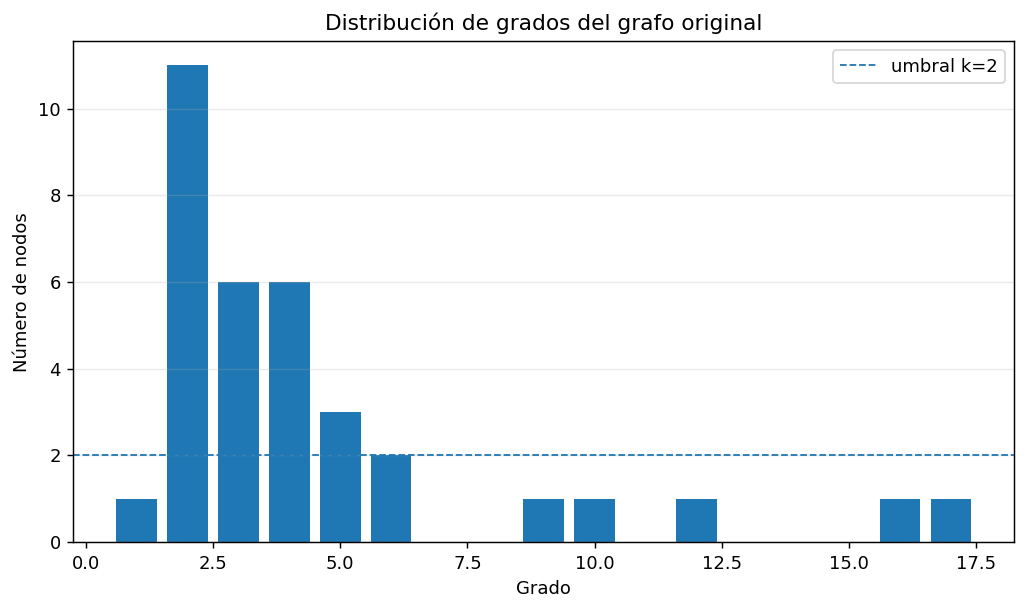

Guardado: outputs_moppo_baselines_autocontenido/fig_00_graph_original.png


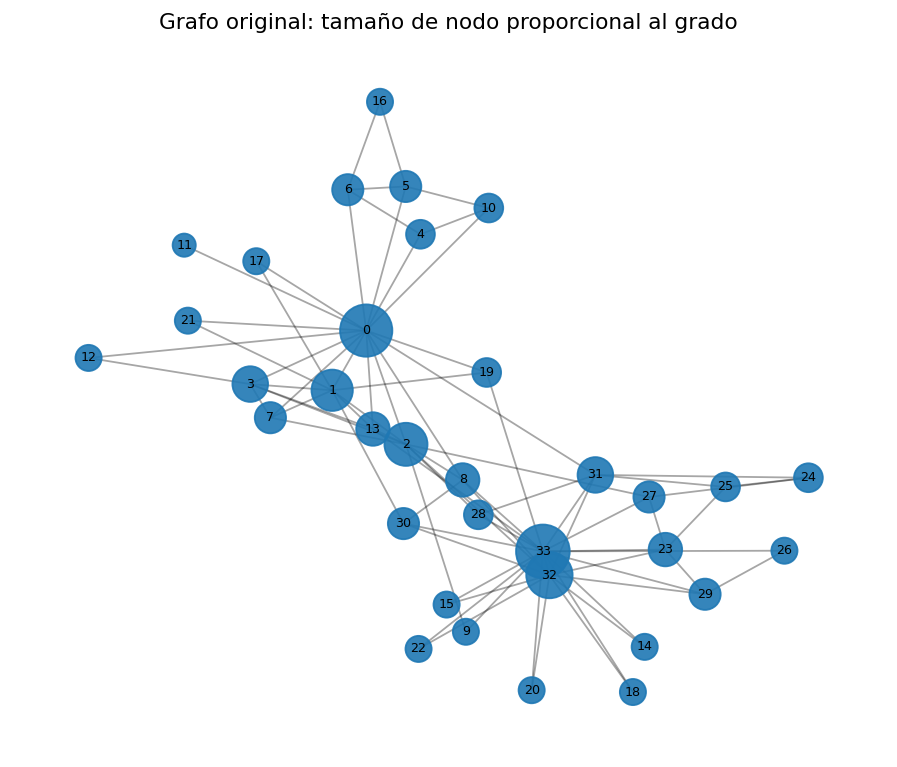

In [6]:
def graph_diagnostics(G, k=2, label='Grafo original'):
    degs = np.array([d for _, d in G.degree()], dtype=float)
    counts = degree_class_counts(G)
    small_classes = {int(deg): int(cnt) for deg, cnt in sorted(counts.items()) if cnt < k}
    diagnostics = {
        'label': label,
        'nodes': G.number_of_nodes(),
        'edges': G.number_of_edges(),
        'density': nx.density(G),
        'avg_degree': float(degs.mean()) if len(degs) else 0.0,
        'degree_std': float(degs.std()) if len(degs) else 0.0,
        'min_degree': int(degs.min()) if len(degs) else 0,
        'max_degree': int(degs.max()) if len(degs) else 0,
        'avg_clustering': nx.average_clustering(G),
        'transitivity': nx.transitivity(G),
        'components': nx.number_connected_components(G),
        'r_priv_initial': compute_k_anonymity_reward(G, k),
        'deficient_degree_classes': small_classes,
        'n_deficient_classes': len(small_classes),
    }
    return diagnostics

diag = graph_diagnostics(G0, K_ANON)
diag_display = pd.DataFrame([{k: v for k, v in diag.items() if k != 'deficient_degree_classes'}])
print('Clases de grado con menos de k nodos:', diag['deficient_degree_classes'])
display(diag_display.T.rename(columns={0: 'valor'}))

plt.figure(figsize=(8, 4.8))
deg_values = [d for _, d in G0.degree()]
unique_deg, deg_counts = np.unique(deg_values, return_counts=True)
plt.bar(unique_deg, deg_counts)
plt.axhline(K_ANON, linestyle='--', linewidth=1, label=f'umbral k={K_ANON}')
plt.xlabel('Grado')
plt.ylabel('Número de nodos')
plt.title('Distribución de grados del grafo original')
plt.grid(True, axis='y', alpha=0.25)
plt.legend()
save_path = OUTPUT_DIR / 'fig_00_degree_distribution_original.png'
plt.tight_layout()
plt.savefig(save_path, dpi=220, bbox_inches='tight')
print('Guardado:', save_path)
plt.show()

plt.figure(figsize=(7, 6))
pos = nx.spring_layout(G0, seed=42)
node_sizes = [120 + 45 * G0.degree(v) for v in G0.nodes()]
nx.draw_networkx_edges(G0, pos, alpha=0.35, width=1.0)
nx.draw_networkx_nodes(G0, pos, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G0, pos, font_size=7)
plt.title('Grafo original: tamaño de nodo proporcional al grado')
plt.axis('off')
save_path = OUTPUT_DIR / 'fig_00_graph_original.png'
plt.tight_layout()
plt.savefig(save_path, dpi=220, bbox_inches='tight')
print('Guardado:', save_path)
plt.show()

## 4. Modelo MOPPO/PPO autocontenido

El actor-crítico recibe la observación completa, incluyendo el peso `alpha`.  
Esto permite entrenar una política condicionada por preferencias: la misma red puede comportarse más agresiva con `alpha` alto y más conservadora con `alpha` bajo.

In [7]:
class MOPPOActorCritic(nn.Module):
    def __init__(self, obs_dim: int, n_actions: int, hidden_dim: int = 128):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        )
        self.actor_head = nn.Linear(hidden_dim, n_actions)
        self.critic_head = nn.Linear(hidden_dim, 1)
        for layer in self.shared:
            if isinstance(layer, nn.Linear):
                nn.init.orthogonal_(layer.weight, gain=math.sqrt(2))
                nn.init.zeros_(layer.bias)
        nn.init.orthogonal_(self.actor_head.weight, gain=0.01)
        nn.init.zeros_(self.actor_head.bias)
        nn.init.orthogonal_(self.critic_head.weight, gain=1.0)
        nn.init.zeros_(self.critic_head.bias)

    def forward(self, obs):
        h = self.shared(obs)
        logits = self.actor_head(h)
        value = self.critic_head(h).squeeze(-1)
        return logits, value

    def get_action(self, obs, deterministic=False, mask=None):
        logits, value = self.forward(obs)
        if mask is not None:
            if mask.dim() == 1:
                mask = mask.unsqueeze(0)
            logits = logits.masked_fill(~mask, -1e9)
        dist = torch.distributions.Categorical(logits=logits)
        action = logits.argmax(dim=-1) if deterministic else dist.sample()
        return action, dist.log_prob(action), dist.entropy(), value

## 5. PPO: rollout, GAE, update y entrenamiento

Esta sección entrena dos tipos de política:

- **MOPPO curriculum/mixed**: `alpha` varía durante el entrenamiento.
- **Fixed-alpha PPO**: entrena una política con un `alpha` fijo, que funciona como baseline del propio repo/notebook existente.

In [8]:
def collect_rollout(env, model, n_steps, device, alpha_range=None, fixed_alpha=None):
    obs_buf, act_buf, logp_buf, val_buf, rew_buf, done_buf, mask_buf = [], [], [], [], [], [], []

    def reset_env():
        if fixed_alpha is not None:
            return env.reset(weight=[fixed_alpha, 1.0 - fixed_alpha])
        return env.reset(alpha_range=alpha_range)

    obs = reset_env()
    for _ in range(n_steps):
        obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        mask_np = env.get_action_mask()
        mask_t = torch.as_tensor(mask_np, dtype=torch.bool, device=device).unsqueeze(0)
        with torch.no_grad():
            action, logp, _, value = model.get_action(obs_t, deterministic=False, mask=mask_t)
        next_obs, reward, done, _ = env.step(action.item())

        obs_buf.append(obs)
        act_buf.append(action.item())
        logp_buf.append(logp.item())
        val_buf.append(value.item())
        rew_buf.append(reward)
        done_buf.append(float(done))
        mask_buf.append(mask_np)

        obs = reset_env() if done else next_obs

    return (
        torch.as_tensor(np.array(obs_buf), dtype=torch.float32, device=device),
        torch.as_tensor(act_buf, dtype=torch.long, device=device),
        torch.as_tensor(logp_buf, dtype=torch.float32, device=device),
        torch.as_tensor(val_buf, dtype=torch.float32, device=device),
        torch.as_tensor(rew_buf, dtype=torch.float32, device=device),
        torch.as_tensor(done_buf, dtype=torch.float32, device=device),
        torch.as_tensor(np.array(mask_buf), dtype=torch.bool, device=device),
    )


def compute_gae(rewards, values, dones, gamma=0.99, lam=0.95):
    n = len(rewards)
    advantages = torch.zeros(n, dtype=torch.float32)
    last_gae = 0.0
    values_cpu = values.detach().cpu()
    rewards_cpu = rewards.detach().cpu()
    dones_cpu = dones.detach().cpu()
    for t in reversed(range(n)):
        next_val = values_cpu[t + 1].item() if t + 1 < n else 0.0
        delta = rewards_cpu[t].item() + gamma * next_val * (1.0 - dones_cpu[t].item()) - values_cpu[t].item()
        last_gae = delta + gamma * lam * (1.0 - dones_cpu[t].item()) * last_gae
        advantages[t] = last_gae
    returns = advantages + values_cpu
    return advantages, returns


def ppo_update(model, optimizer, obs, actions, old_logps, returns, advantages, masks,
               clip_eps=0.2, vf_coef=0.5, ent_coef=0.03, n_epochs=4, batch_size=64):
    n = len(obs)
    returns = returns.to(obs.device)
    advantages = advantages.to(obs.device)
    total_loss = 0.0
    n_batches = 0

    for _ in range(n_epochs):
        idx = torch.randperm(n, device=obs.device)
        for start in range(0, n, batch_size):
            mb = idx[start:start + batch_size]
            logits, values = model(obs[mb])
            logits = logits.masked_fill(~masks[mb], -1e9)
            dist = torch.distributions.Categorical(logits=logits)
            logps = dist.log_prob(actions[mb])
            entropy = dist.entropy().mean()

            ratio = (logps - old_logps[mb]).exp()
            adv = advantages[mb]
            adv = (adv - adv.mean()) / (adv.std() + 1e-8)

            policy_loss = -torch.min(
                ratio * adv,
                torch.clamp(ratio, 1.0 - clip_eps, 1.0 + clip_eps) * adv,
            ).mean()
            value_loss = (values - returns[mb]).pow(2).mean()
            loss = policy_loss + vf_coef * value_loss - ent_coef * entropy

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()

            total_loss += float(loss.item())
            n_batches += 1
    return total_loss / max(n_batches, 1)


def train_ppo_policy(G0, seed=0, fixed_alpha=None, n_iter=50, n_steps=256,
                     hidden_dim=128, curriculum=True, verbose=False):
    set_global_seed(seed)
    env = GraphAnonEnv(G0, k=K_ANON, T=EPISODE_LEN)
    model = MOPPOActorCritic(env.obs_dim, env.n_actions, hidden_dim=hidden_dim).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    history = []

    for iteration in range(n_iter):
        alpha_range = None
        # Curriculum suave: primero privacidad, luego utilidad, luego mezcla completa.
        if fixed_alpha is None and curriculum:
            if iteration < int(0.25 * n_iter):
                alpha_range = (0.85, 1.0)
            elif iteration < int(0.50 * n_iter):
                alpha_range = (0.0, 0.15)
            else:
                alpha_range = (0.0, 1.0)

        obs, acts, logps, vals, rews, dones, masks = collect_rollout(
            env, model, n_steps, DEVICE, alpha_range=alpha_range, fixed_alpha=fixed_alpha
        )
        adv, ret = compute_gae(rews, vals, dones, GAMMA, LAMBDA_GAE)
        loss = ppo_update(model, optimizer, obs, acts, logps, ret, adv, masks, clip_eps=CLIP_EPS)
        history.append({'iter': iteration, 'loss': loss, 'mean_reward': float(rews.mean().item())})

        if verbose and ((iteration + 1) % max(1, n_iter // 5) == 0 or iteration == 0):
            label = 'MOPPO' if fixed_alpha is None else f'Fixed-alpha={fixed_alpha}'
            print(f'{label} seed={seed} iter={iteration+1:04d}/{n_iter} loss={loss:.4f} mean_r={rews.mean().item():.4f}')

    model.eval()
    return model, pd.DataFrame(history)

## 6. Baselines autocontenidos

Incluimos cuatro familias de comparación:

1. **Random Masked**: elige una acción válida al azar.
2. **Fixed-alpha PPO**: PPO entrenado con `alpha` fijo. Es el baseline que ya existía conceptualmente en el repo/notebook de comparación.
3. **Greedy Liu-Terzi style**: heurística clásica que busca mejorar k-anonimato con el menor deterioro estructural posible.
4. **Alpha-Greedy Rollout**: baseline nuevo. Evalúa acciones candidatas usando exactamente el escalar `alpha*r_priv + (1-alpha)*r_util`, por lo que cambia su comportamiento según el trade-off pedido.

In [9]:
def final_metrics(env, alpha, method, seed, episode, extra=None):
    r_priv = compute_k_anonymity_reward(env.G, env.k)
    r_util = compute_utility_reward(env.G, env.G0)
    row = {
        'method': method,
        'seed': seed,
        'episode': episode,
        'alpha': float(alpha),
        'r_priv': float(r_priv),
        'r_util': float(r_util),
        'score': scalar_score(r_priv, r_util, alpha),
        'edge_change_ratio': edge_change_ratio(env.G, env.G0),
        'final_edges': env.G.number_of_edges(),
        'final_clustering': nx.average_clustering(env.G),
    }
    if extra:
        row.update(extra)
    return row


def run_random_masked_policy(G0, seed, alpha, n_episodes=3):
    rows = []
    rng = np.random.default_rng(seed + int(alpha * 1000) + 101)
    for ep in range(n_episodes):
        env = GraphAnonEnv(G0, k=K_ANON, T=EPISODE_LEN)
        env.reset(seed=seed + ep, weight=[alpha, 1.0 - alpha])
        done = False
        steps = 0
        while not done:
            valid = np.flatnonzero(env.get_action_mask())
            action = int(rng.choice(valid))
            _, _, done, _ = env.step(action)
            steps += 1
        rows.append(final_metrics(env, alpha, 'Random Masked', seed, ep, {'steps': steps}))
    return rows


def candidate_actions_from_mask(env, max_candidates=None, rng=None):
    valid = np.flatnonzero(env.get_action_mask())
    valid = valid[valid != env.NO_OP]
    if max_candidates is not None and len(valid) > max_candidates:
        rng = rng or np.random.default_rng(0)
        valid = rng.choice(valid, size=max_candidates, replace=False)
    return list(map(int, valid))


def simulate_action_score(env, action, alpha, use_true_utility=True):
    G_tmp = env.G.copy()
    if action != env.NO_OP:
        u, v = env.all_edges[action]
        if G_tmp.has_edge(u, v):
            G_tmp.remove_edge(u, v)
        else:
            G_tmp.add_edge(u, v)
    r_priv = compute_k_anonymity_reward(G_tmp, env.k)
    if use_true_utility:
        r_util = compute_utility_reward(G_tmp, env.G0)
    else:
        # proxy rápido si se quisiera acelerar demasiado
        r_util = -edge_change_ratio(G_tmp, env.G0)
    return scalar_score(r_priv, r_util, alpha), r_priv, r_util


def run_greedy_liu_terzi_style(G0, seed, alpha, n_episodes=3, max_candidates=50):
    '''
    Baseline heurístico clásico:
    - prioriza mejorar privacidad/k-anonimato;
    - usa utilidad solo para desempatar;
    - se detiene si no encuentra mejora razonable.
    '''
    rows = []
    rng = np.random.default_rng(seed + int(alpha * 1000) + 202)
    for ep in range(n_episodes):
        env = GraphAnonEnv(G0, k=K_ANON, T=EPISODE_LEN)
        env.reset(seed=seed + ep, weight=[alpha, 1.0 - alpha])
        steps = 0
        done = False
        no_improve = 0

        while not done:
            current_priv = compute_k_anonymity_reward(env.G, env.k)
            current_util = compute_utility_reward(env.G, env.G0)
            candidates = candidate_actions_from_mask(env, max_candidates=max_candidates, rng=rng)
            if len(candidates) == 0:
                action = env.NO_OP
            else:
                scored = []
                for a in candidates:
                    _, rp, ru = simulate_action_score(env, a, alpha=1.0, use_true_utility=False)
                    # Orden clásico: primero privacidad, luego utilidad, luego menos cambios.
                    G_tmp = env.G.copy()
                    u, v = env.all_edges[a]
                    if G_tmp.has_edge(u, v):
                        G_tmp.remove_edge(u, v)
                    else:
                        G_tmp.add_edge(u, v)
                    scored.append((rp, ru, -edge_change_ratio(G_tmp, env.G0), a))
                scored.sort(reverse=True)
                best_priv, best_util, _, best_action = scored[0]
                if best_priv > current_priv + 1e-12 or (abs(best_priv - current_priv) < 1e-12 and best_util > current_util):
                    action = best_action
                    no_improve = 0
                else:
                    no_improve += 1
                    action = env.NO_OP

            _, _, done, _ = env.step(action)
            steps += 1
            if no_improve >= 3:
                # rellena con no-op hasta terminar para conservar la misma longitud de episodio
                while not done:
                    _, _, done, _ = env.step(env.NO_OP)
                    steps += 1

        rows.append(final_metrics(env, alpha, 'Greedy Liu-Terzi style', seed, ep, {'steps': steps}))
    return rows


def run_alpha_greedy_rollout(G0, seed, alpha, n_episodes=3, max_candidates=50):
    '''
    Nuevo baseline propuesto:
    evalúa acciones candidatas con el mismo escalar multiobjetivo que usa PPO:
        score = alpha * r_priv + (1-alpha) * r_util.
    Por eso, con alpha alto modifica más para privacidad; con alpha bajo tiende a conservar utilidad.
    '''
    rows = []
    rng = np.random.default_rng(seed + int(alpha * 1000) + 303)
    for ep in range(n_episodes):
        env = GraphAnonEnv(G0, k=K_ANON, T=EPISODE_LEN)
        env.reset(seed=seed + ep, weight=[alpha, 1.0 - alpha])
        steps = 0
        done = False
        stagnant = 0

        while not done:
            current_rp = compute_k_anonymity_reward(env.G, env.k)
            current_ru = compute_utility_reward(env.G, env.G0)
            current_score = scalar_score(current_rp, current_ru, alpha)
            candidates = candidate_actions_from_mask(env, max_candidates=max_candidates, rng=rng)
            # Siempre considera no-op para que alpha bajo pueda preservar utilidad.
            candidates = candidates + [env.NO_OP]

            scored = []
            for a in candidates:
                sc, rp, ru = simulate_action_score(env, a, alpha=alpha, use_true_utility=False)
                scored.append((sc, rp, ru, a))
            scored.sort(reverse=True)
            best_score, best_rp, best_ru, best_action = scored[0]

            if best_score > current_score + 1e-10:
                action = best_action
                stagnant = 0
            else:
                action = env.NO_OP
                stagnant += 1

            _, _, done, _ = env.step(action)
            steps += 1
            if stagnant >= 3:
                while not done:
                    _, _, done, _ = env.step(env.NO_OP)
                    steps += 1

        rows.append(final_metrics(env, alpha, 'Alpha-Greedy Rollout', seed, ep, {'steps': steps}))
    return rows


def evaluate_torch_policy(G0, model, seed, alpha, method, n_episodes=3, deterministic=True):
    rows = []
    for ep in range(n_episodes):
        env = GraphAnonEnv(G0, k=K_ANON, T=EPISODE_LEN)
        obs = env.reset(seed=seed + ep, weight=[alpha, 1.0 - alpha])
        done = False
        steps = 0
        while not done:
            obs_t = torch.as_tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            mask_t = torch.as_tensor(env.get_action_mask(), dtype=torch.bool, device=DEVICE).unsqueeze(0)
            with torch.no_grad():
                action, _, _, _ = model.get_action(obs_t, deterministic=deterministic, mask=mask_t)
            obs, _, done, _ = env.step(int(action.item()))
            steps += 1
        rows.append(final_metrics(env, alpha, method, seed, ep, {'steps': steps}))
    return rows

## 6.1 Lectura conceptual de los métodos comparados

Los métodos se comparan bajo el mismo criterio escalarizado:

\[
J_lpha = lpha r_{priv} + (1-lpha) r_{util}.
\]

La diferencia está en cómo cada método decide modificar el grafo:

- **MOPPO** aprende una política condicionada por preferencias, por lo que una sola red recibe `alpha` como parte de la observación y debería adaptarse a distintos compromisos privacidad-utilidad.
- **Fixed-alpha PPO** representa el baseline de aprendizaje ya existente: entrena una política separada para una preferencia fija. Es útil para evaluar si el condicionamiento de MOPPO aporta flexibilidad.
- **Random Masked** es una línea base inferior; usa la máscara de acciones válidas, pero no optimiza explícitamente el objetivo.
- **Greedy Liu-Terzi style** aproxima un baseline heurístico clásico: prioriza reducir violaciones de k-anonimato y usa utilidad como desempate.
- **Alpha-Greedy Rollout** es el baseline nuevo: toma decisiones greedy usando el mismo `alpha` de evaluación, por lo que es una heurística multiobjetivo explícita.

Esta separación permite distinguir tres familias: aprendizaje condicionado, aprendizaje por preferencia fija y heurísticos no aprendidos.

## 7. Experimentos con seeds

Esta celda entrena y evalúa:

- MOPPO condicionado por peso.
- PPO de `alpha` fijo para cada alpha en `ALPHAS`.
- Random Masked.
- Greedy Liu-Terzi style.
- Alpha-Greedy Rollout, el baseline nuevo.

En modo demo tarda poco; en modo final puede tardar varios minutos dependiendo del número de seeds e iteraciones.

In [10]:
all_rows = []
train_histories = []
G0 = make_graph(GRAPH_NAME, N_NODES_RANDOM, seed=0)

print('Grafo base')
print(' nodes =', G0.number_of_nodes())
print(' edges =', G0.number_of_edges())
print(' clustering inicial =', round(nx.average_clustering(G0), 4))
print(' r_priv inicial =', round(compute_k_anonymity_reward(G0, K_ANON), 4))
print()

for seed in SEEDS:
    print('=' * 70)
    print(f'Seed {seed}')

    # 1) MOPPO / PPO condicionado por alpha
    moppo_model, hist = train_ppo_policy(
        G0, seed=seed, fixed_alpha=None, n_iter=N_ITER_MOPPO, n_steps=N_STEPS,
        hidden_dim=HIDDEN_DIM, curriculum=True, verbose=True
    )
    hist['method'] = 'MOPPO'
    hist['seed'] = seed
    train_histories.append(hist)

    for alpha in ALPHAS:
        all_rows.extend(evaluate_torch_policy(G0, moppo_model, seed, alpha, 'MOPPO', N_EPISODES_EVAL))

    # 2) Fixed-alpha PPO: baseline ya usado en el repo/notebook conceptual
    if RUN_FIXED_PPO:
        for alpha in ALPHAS:
            fixed_model, hist_f = train_ppo_policy(
                G0, seed=seed, fixed_alpha=float(alpha), n_iter=N_ITER_FIXED, n_steps=N_STEPS,
                hidden_dim=HIDDEN_DIM, curriculum=False, verbose=False
            )
            hist_f['method'] = f'Fixed-alpha PPO ({alpha:.2f})'
            hist_f['seed'] = seed
            hist_f['alpha_train'] = alpha
            train_histories.append(hist_f)
            all_rows.extend(evaluate_torch_policy(G0, fixed_model, seed, alpha, 'Fixed-alpha PPO', N_EPISODES_EVAL))
            del fixed_model
            gc.collect()
    else:
        print('Fixed-alpha PPO desactivado en esta corrida rápida.')

    # 3) Heurísticos / baselines no aprendidos
    for alpha in ALPHAS:
        all_rows.extend(run_random_masked_policy(G0, seed, alpha, N_EPISODES_EVAL))
        all_rows.extend(run_greedy_liu_terzi_style(G0, seed, alpha, N_EPISODES_EVAL))
        all_rows.extend(run_alpha_greedy_rollout(G0, seed, alpha, N_EPISODES_EVAL))

results = pd.DataFrame(all_rows)
train_history = pd.concat(train_histories, ignore_index=True) if train_histories else pd.DataFrame()

results_path = OUTPUT_DIR / 'raw_results.csv'
train_path = OUTPUT_DIR / 'train_history.csv'
results.to_csv(results_path, index=False)
train_history.to_csv(train_path, index=False)

print('\nResultados guardados en:', results_path)
print('Historial de entrenamiento guardado en:', train_path)
display(results.head())

Grafo base
 nodes = 34
 edges = 78
 clustering inicial = 0.5706
 r_priv inicial = -0.1765

Seed 0
MOPPO seed=0 iter=0001/15 loss=0.0471 mean_r=-0.0840
MOPPO seed=0 iter=0003/15 loss=0.0232 mean_r=-0.0768
MOPPO seed=0 iter=0006/15 loss=0.1628 mean_r=-0.1287
MOPPO seed=0 iter=0009/15 loss=0.1530 mean_r=-0.1205
MOPPO seed=0 iter=0012/15 loss=0.0622 mean_r=-0.1047
MOPPO seed=0 iter=0015/15 loss=0.0007 mean_r=-0.1009
Seed 1
MOPPO seed=1 iter=0001/15 loss=0.1683 mean_r=-0.0661
MOPPO seed=1 iter=0003/15 loss=0.0489 mean_r=-0.0893
MOPPO seed=1 iter=0006/15 loss=0.2036 mean_r=-0.1194
MOPPO seed=1 iter=0009/15 loss=0.0497 mean_r=-0.0743
MOPPO seed=1 iter=0012/15 loss=0.1173 mean_r=-0.1277
MOPPO seed=1 iter=0015/15 loss=-0.0118 mean_r=-0.1000

Resultados guardados en: outputs_moppo_baselines_autocontenido/raw_results.csv
Historial de entrenamiento guardado en: outputs_moppo_baselines_autocontenido/train_history.csv


,method,seed,episode,alpha,r_priv,r_util,score,edge_change_ratio,final_edges,final_clustering,steps
0,MOPPO,0,0,0.0000,-0.1176,-0.0005,-0.0005,0.0128,77,0.5701,25
1,MOPPO,0,1,0.0000,-0.1176,-0.0005,-0.0005,0.0128,77,0.5701,25
2,MOPPO,0,0,0.2500,-0.1176,-0.0005,-0.0298,0.0128,77,0.5701,25
3,MOPPO,0,1,0.2500,-0.1176,-0.0005,-0.0298,0.0128,77,0.5701,25
4,MOPPO,0,0,0.5000,-0.1176,-0.0005,-0.0591,0.0128,77,0.5701,25


## 8. Resumen estadístico

Promediamos por método y `alpha`. También calculamos un resumen global por método con:

- media de privacidad;
- media de utilidad;
- score ponderado;
- proporción de aristas modificadas;
- hipervolumen aproximado del frente privacidad-utilidad.

In [11]:
summary_alpha = (
    results
    .groupby(['method', 'alpha'], as_index=False)
    .agg(
        r_priv_mean=('r_priv', 'mean'),
        r_priv_std=('r_priv', 'std'),
        r_util_mean=('r_util', 'mean'),
        r_util_std=('r_util', 'std'),
        score_mean=('score', 'mean'),
        score_std=('score', 'std'),
        edge_change_mean=('edge_change_ratio', 'mean'),
        edge_change_std=('edge_change_ratio', 'std'),
        n=('score', 'size')
    )
)

method_rows = []
for method, dfm in results.groupby('method'):
    pts = list(zip(dfm['r_priv'], dfm['r_util']))
    method_rows.append({
        'method': method,
        'r_priv_mean': dfm['r_priv'].mean(),
        'r_util_mean': dfm['r_util'].mean(),
        'score_mean': dfm['score'].mean(),
        'edge_change_mean': dfm['edge_change_ratio'].mean(),
        'hypervolume': hypervolume_2d(pts, reference=(-1.0, -1.0)),
        'pareto_size': len(compute_pareto_front(pts)),
        'n': len(dfm),
    })
summary_method = pd.DataFrame(method_rows).sort_values('hypervolume', ascending=False)

summary_alpha.to_csv(OUTPUT_DIR / 'summary_by_alpha.csv', index=False)
summary_method.to_csv(OUTPUT_DIR / 'summary_by_method.csv', index=False)

print('Resumen por método:')
display(summary_method)
print('\nResumen por método y alpha:')
display(summary_alpha.head(20))

Resumen por método:


,method,r_priv_mean,r_util_mean,score_mean,edge_change_mean,hypervolume,pareto_size,n
4,Random Masked,-0.0294,-0.1076,-0.0713,0.1955,0.9845,1,20
2,Greedy Liu-Terzi style,-0.0250,-0.0445,-0.0369,0.0288,0.9697,2,20
3,MOPPO,-0.1176,-0.0035,-0.0602,0.0128,0.8819,1,20
0,Alpha-Greedy Rollout,-0.0574,-0.0257,-0.0225,0.0212,0.8235,3,20
1,Fixed-alpha PPO,-0.1471,-0.0206,-0.0841,0.0179,0.7913,4,20



Resumen por método y alpha:


,method,alpha,r_priv_mean,r_priv_std,r_util_mean,r_util_std,score_mean,score_std,edge_change_mean,edge_change_std,n
0,Alpha-Greedy Rollout,0.0000,-0.1765,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,4
1,Alpha-Greedy Rollout,0.2500,-0.0294,0.0000,-0.0258,0.0103,-0.0267,0.0077,0.0256,0.0000,4
2,Alpha-Greedy Rollout,0.5000,-0.0294,0.0000,-0.0230,0.0175,-0.0262,0.0087,0.0256,0.0000,4
3,Alpha-Greedy Rollout,0.7500,-0.0221,0.0147,-0.0555,0.0609,-0.0304,0.0046,0.0288,0.0064,4
4,Alpha-Greedy Rollout,1.0000,-0.0294,0.0000,-0.0242,0.0130,-0.0294,0.0000,0.0256,0.0000,4
5,Fixed-alpha PPO,0.0000,-0.1471,0.1019,-0.0399,0.0414,-0.0399,0.0414,0.0256,0.0148,4
6,Fixed-alpha PPO,0.2500,-0.1618,0.0170,-0.0122,0.0012,-0.0496,0.0033,0.0128,0.0000,4
7,Fixed-alpha PPO,0.5000,-0.1471,0.0340,-0.0245,0.0212,-0.0858,0.0064,0.0128,0.0000,4
8,Fixed-alpha PPO,0.7500,-0.1471,0.0340,-0.0095,0.0013,-0.1127,0.0258,0.0128,0.0000,4
9,Fixed-alpha PPO,1.0000,-0.1324,0.0849,-0.0167,0.0151,-0.1324,0.0849,0.0256,0.0148,4


## 8.1 Métricas ampliadas: incertidumbre, regret y dominancia empírica

El promedio por método es útil, pero no suficiente. En problemas multiobjetivo interesa saber estabilidad, pérdida relativa contra el mejor método por preferencia, dominancia empírica y ranking agregado. Estos análisis no sustituyen el frente de Pareto, pero ayudan a defender la comparación de manera más rigurosa.

In [12]:
def bootstrap_ci(values, n_boot=2000, ci=0.95, seed=123):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    if len(values) == 0:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    boots = []
    for _ in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        boots.append(sample.mean())
    lo = np.quantile(boots, (1 - ci) / 2)
    hi = np.quantile(boots, 1 - (1 - ci) / 2)
    return float(lo), float(hi)

ci_rows = []
for method, dfm in results.groupby('method'):
    row = {'method': method, 'n': len(dfm)}
    for metric in ['r_priv', 'r_util', 'score', 'edge_change_ratio']:
        lo, hi = bootstrap_ci(dfm[metric].values, seed=abs(hash((method, metric))) % (2**32))
        row[f'{metric}_mean'] = dfm[metric].mean()
        row[f'{metric}_ci_low'] = lo
        row[f'{metric}_ci_high'] = hi
    ci_rows.append(row)
ci_table = pd.DataFrame(ci_rows).sort_values('score_mean', ascending=False)
ci_table.to_csv(OUTPUT_DIR / 'bootstrap_confidence_intervals.csv', index=False)
display(ci_table)

alpha_best = summary_alpha.groupby('alpha')['score_mean'].max().rename('best_score_alpha')
regret_table = summary_alpha.merge(alpha_best, on='alpha')
regret_table['regret_to_best_alpha'] = regret_table['best_score_alpha'] - regret_table['score_mean']
regret_table = regret_table.sort_values(['alpha', 'regret_to_best_alpha'])
regret_table.to_csv(OUTPUT_DIR / 'regret_by_alpha.csv', index=False)
display(regret_table[['method', 'alpha', 'score_mean', 'best_score_alpha', 'regret_to_best_alpha']])

methods = sorted(results['method'].unique())
win_matrix = pd.DataFrame(0.0, index=methods, columns=methods)
for m1 in methods:
    for m2 in methods:
        if m1 == m2:
            win_matrix.loc[m1, m2] = np.nan
            continue
        wins = []
        for alpha, dfa in results.groupby('alpha'):
            s1 = dfa[dfa['method'] == m1]['score'].values
            s2 = dfa[dfa['method'] == m2]['score'].values
            if len(s1) and len(s2):
                wins.append((s1[:, None] > s2[None, :]).mean())
        win_matrix.loc[m1, m2] = float(np.mean(wins)) if wins else np.nan
win_matrix.to_csv(OUTPUT_DIR / 'pairwise_win_rate_matrix.csv')
print('Matriz de tasa de victoria por score; fila vence a columna.')
display(win_matrix)

rank_df = summary_method.copy()
rank_df['rank_hv'] = rank_df['hypervolume'].rank(ascending=False, method='average')
rank_df['rank_score'] = rank_df['score_mean'].rank(ascending=False, method='average')
rank_df['rank_priv'] = rank_df['r_priv_mean'].rank(ascending=False, method='average')
rank_df['rank_util'] = rank_df['r_util_mean'].rank(ascending=False, method='average')
rank_df['rank_edge_cost'] = rank_df['edge_change_mean'].rank(ascending=True, method='average')
rank_cols = ['rank_hv', 'rank_score', 'rank_priv', 'rank_util', 'rank_edge_cost']
rank_df['mean_rank'] = rank_df[rank_cols].mean(axis=1)
rank_df = rank_df.sort_values('mean_rank')
rank_df.to_csv(OUTPUT_DIR / 'aggregate_ranking.csv', index=False)
display(rank_df[['method'] + rank_cols + ['mean_rank']])

,method,n,r_priv_mean,r_priv_ci_low,r_priv_ci_high,r_util_mean,r_util_ci_low,r_util_ci_high,score_mean,score_ci_low,score_ci_high,edge_change_ratio_mean,edge_change_ratio_ci_low,edge_change_ratio_ci_high
0,Alpha-Greedy Rollout,20,-0.0574,-0.0868,-0.0338,-0.0257,-0.0406,-0.0146,-0.0225,-0.0276,-0.0169,0.0212,0.0160,0.0256
2,Greedy Liu-Terzi style,20,-0.0250,-0.0294,-0.0206,-0.0445,-0.0677,-0.0243,-0.0369,-0.0579,-0.0216,0.0288,0.0256,0.0327
3,MOPPO,20,-0.1176,-0.1176,-0.1176,-0.0035,-0.0052,-0.0020,-0.0602,-0.0778,-0.0427,0.0128,0.0128,0.0128
4,Random Masked,20,-0.0294,-0.0500,-0.0132,-0.1076,-0.1322,-0.0865,-0.0713,-0.0973,-0.0490,0.1955,0.1705,0.2212
1,Fixed-alpha PPO,20,-0.1471,-0.1721,-0.1221,-0.0206,-0.0310,-0.0118,-0.0841,-0.1099,-0.0628,0.0179,0.0141,0.0231


,method,alpha,score_mean,best_score_alpha,regret_to_best_alpha
0,Alpha-Greedy Rollout,0.0000,0.0000,0.0000,0.0000
15,MOPPO,0.0000,-0.0025,0.0000,0.0025
5,Fixed-alpha PPO,0.0000,-0.0399,0.0000,0.0399
10,Greedy Liu-Terzi style,0.0000,-0.0844,0.0000,0.0844
20,Random Masked,0.0000,-0.1214,0.0000,0.1214
11,Greedy Liu-Terzi style,0.2500,-0.0250,-0.0250,0.0000
1,Alpha-Greedy Rollout,0.2500,-0.0267,-0.0250,0.0017
16,MOPPO,0.2500,-0.0313,-0.0250,0.0063
6,Fixed-alpha PPO,0.2500,-0.0496,-0.0250,0.0246
21,Random Masked,0.2500,-0.0625,-0.0250,0.0374


Matriz de tasa de victoria por score; fila vence a columna.


,Alpha-Greedy Rollout,Fixed-alpha PPO,Greedy Liu-Terzi style,MOPPO,Random Masked
Alpha-Greedy Rollout,NaN,1.0000,0.4375,0.9250,0.7125
Fixed-alpha PPO,0.0000,NaN,0.1500,0.2000,0.3750
Greedy Liu-Terzi style,0.3500,0.8500,NaN,0.7750,0.6625
MOPPO,0.0750,0.8000,0.2250,NaN,0.5500
Random Masked,0.2875,0.6250,0.3125,0.4500,NaN


,method,rank_hv,rank_score,rank_priv,rank_util,rank_edge_cost,mean_rank
3,MOPPO,3.0000,3.0000,4.0000,1.0000,1.0000,2.4000
2,Greedy Liu-Terzi style,2.0000,2.0000,1.0000,4.0000,4.0000,2.6000
0,Alpha-Greedy Rollout,4.0000,1.0000,3.0000,3.0000,3.0000,2.8000
4,Random Masked,1.0000,4.0000,2.0000,5.0000,5.0000,3.4000
1,Fixed-alpha PPO,5.0000,5.0000,5.0000,2.0000,2.0000,3.8000


## 9. Gráficas comparativas

1. Frente privacidad-utilidad.
2. Score promedio por alpha.
3. Hipervolumen por método.
4. Porcentaje de aristas modificadas.
5. Evolución de entrenamiento PPO/MOPPO.

Guardado: outputs_moppo_baselines_autocontenido/fig_01_pareto_privacy_utility.png


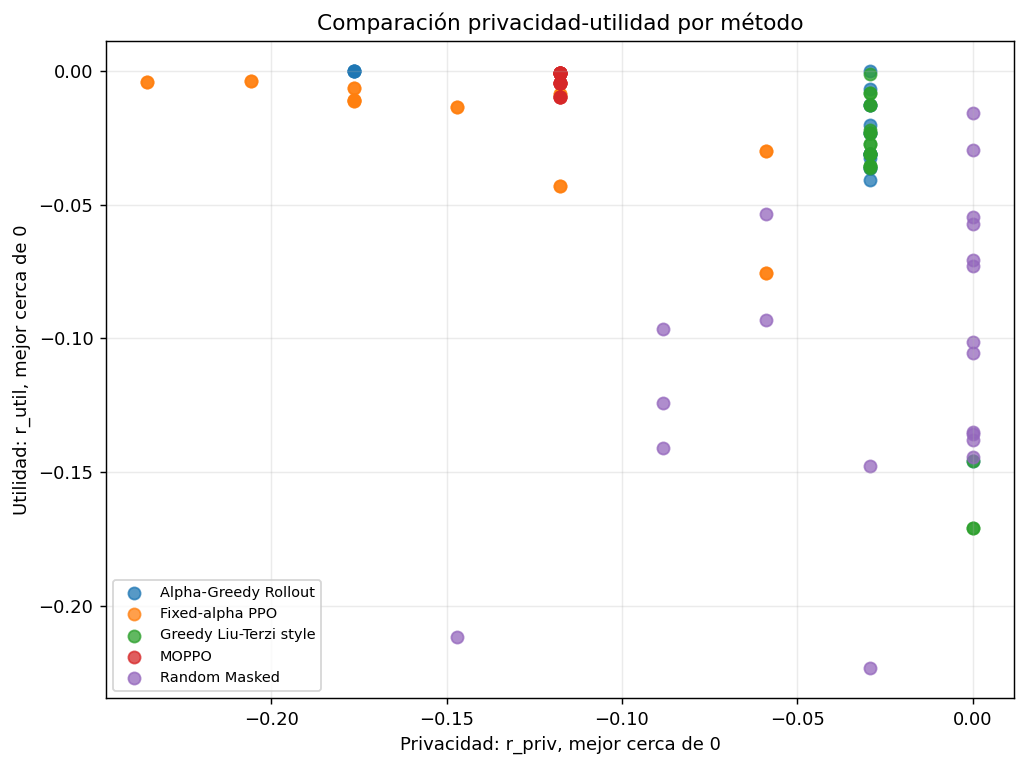

Guardado: outputs_moppo_baselines_autocontenido/fig_02_score_by_alpha.png


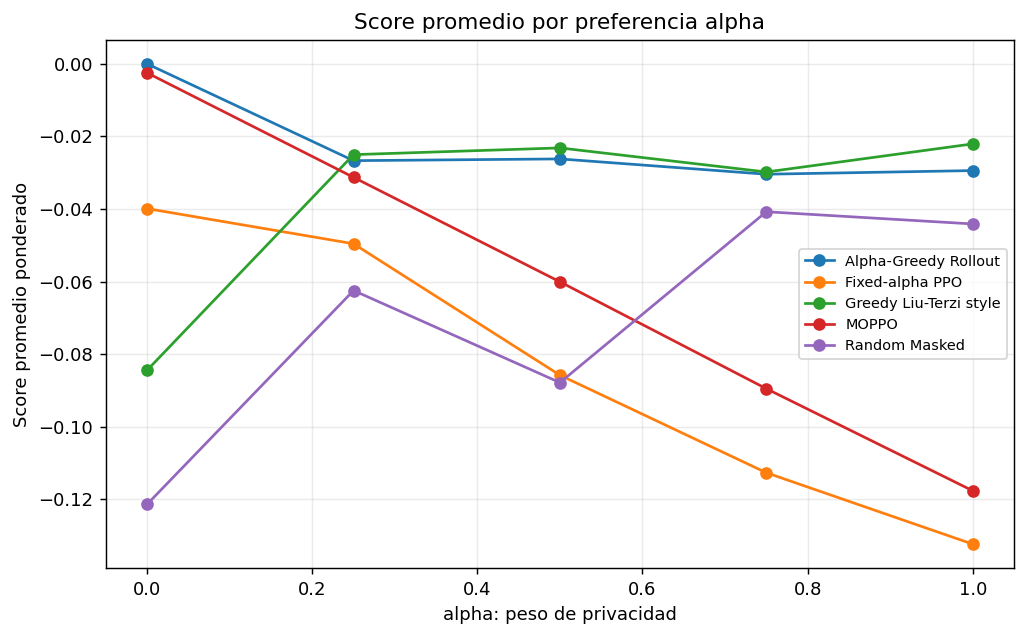

Guardado: outputs_moppo_baselines_autocontenido/fig_03_hypervolume_by_method.png


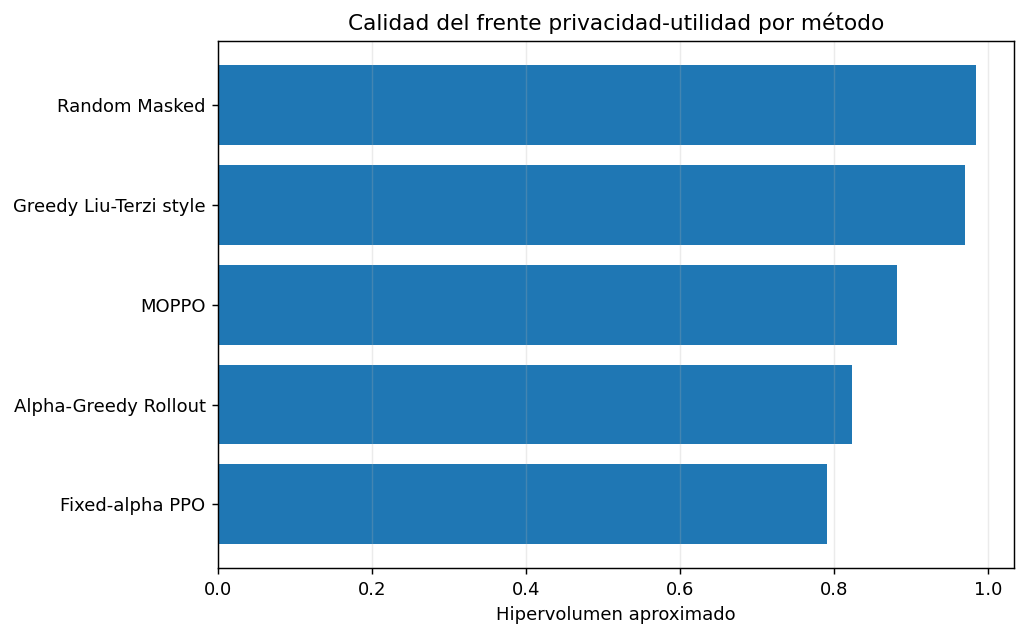

Guardado: outputs_moppo_baselines_autocontenido/fig_04_edge_change_by_method.png


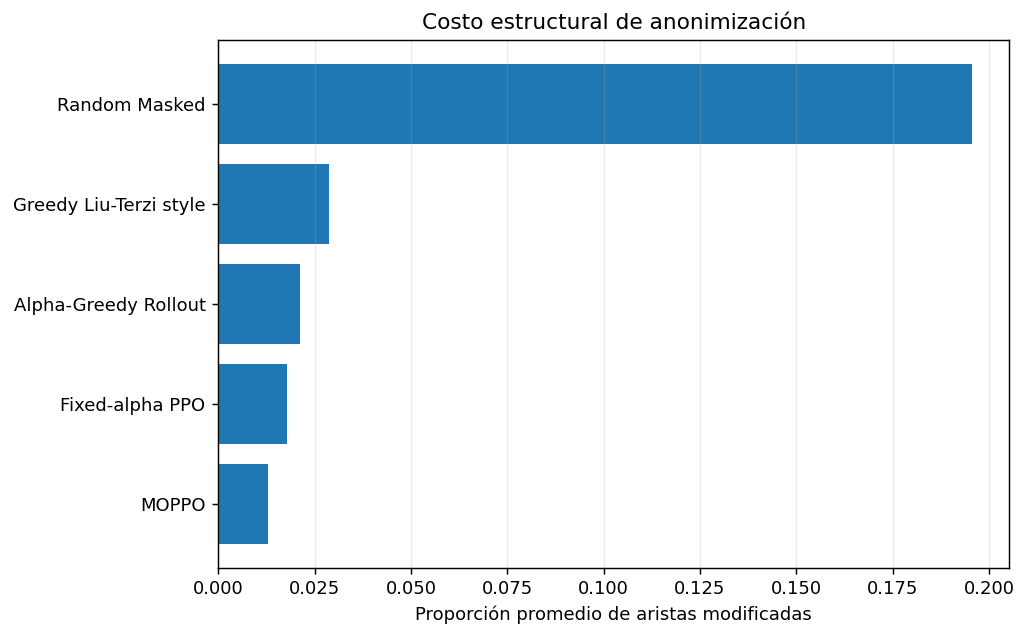

Guardado: outputs_moppo_baselines_autocontenido/fig_05_training_moppo.png


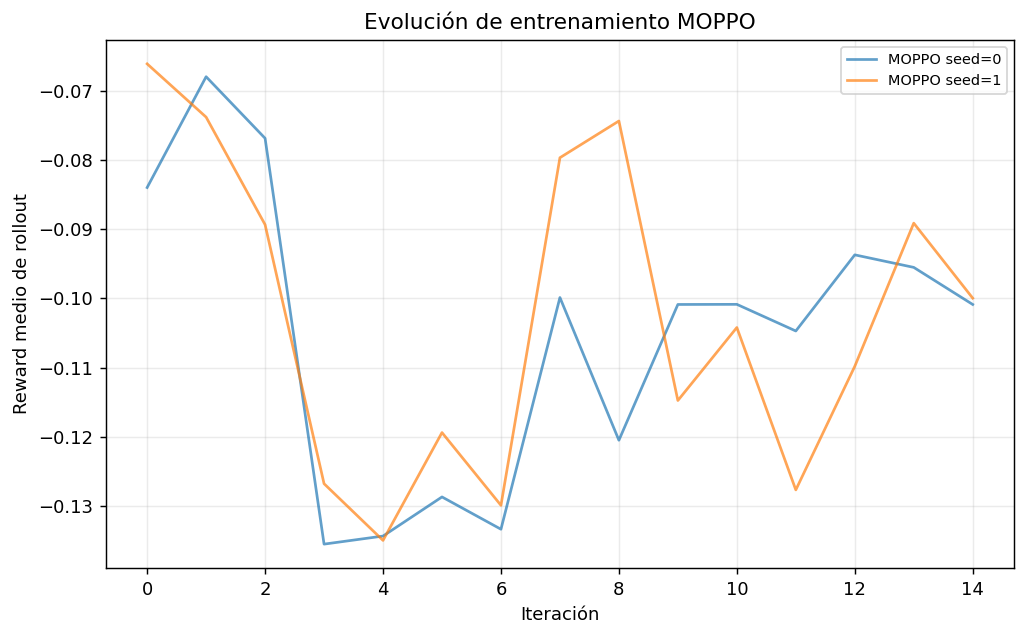

In [13]:
def savefig(name):
    path = OUTPUT_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches='tight')
    print('Guardado:', path)

# 1) Frente privacidad-utilidad
plt.figure(figsize=(8, 6))
for method, dfm in results.groupby('method'):
    plt.scatter(dfm['r_priv'], dfm['r_util'], s=45, alpha=0.75, label=method)
plt.xlabel('Privacidad: r_priv, mejor cerca de 0')
plt.ylabel('Utilidad: r_util, mejor cerca de 0')
plt.title('Comparación privacidad-utilidad por método')
plt.grid(True, alpha=0.25)
plt.legend(fontsize=8)
savefig('fig_01_pareto_privacy_utility.png')
plt.show()

# 2) Score promedio por alpha
plt.figure(figsize=(8, 5))
for method, dfm in summary_alpha.groupby('method'):
    dfm = dfm.sort_values('alpha')
    plt.plot(dfm['alpha'], dfm['score_mean'], marker='o', label=method)
plt.xlabel('alpha: peso de privacidad')
plt.ylabel('Score promedio ponderado')
plt.title('Score promedio por preferencia alpha')
plt.grid(True, alpha=0.25)
plt.legend(fontsize=8)
savefig('fig_02_score_by_alpha.png')
plt.show()

# 3) Hipervolumen
plt.figure(figsize=(8, 5))
df_hv = summary_method.sort_values('hypervolume')
plt.barh(df_hv['method'], df_hv['hypervolume'])
plt.xlabel('Hipervolumen aproximado')
plt.title('Calidad del frente privacidad-utilidad por método')
plt.grid(True, axis='x', alpha=0.25)
savefig('fig_03_hypervolume_by_method.png')
plt.show()

# 4) Aristas modificadas
plt.figure(figsize=(8, 5))
df_edges = summary_method.sort_values('edge_change_mean')
plt.barh(df_edges['method'], df_edges['edge_change_mean'])
plt.xlabel('Proporción promedio de aristas modificadas')
plt.title('Costo estructural de anonimización')
plt.grid(True, axis='x', alpha=0.25)
savefig('fig_04_edge_change_by_method.png')
plt.show()

# 5) Historial de entrenamiento, si existe
if not train_history.empty:
    plt.figure(figsize=(8, 5))
    plot_hist = train_history[train_history['method'].isin(['MOPPO'])]
    if len(plot_hist):
        for seed, dfs in plot_hist.groupby('seed'):
            plt.plot(dfs['iter'], dfs['mean_reward'], alpha=0.7, label=f'MOPPO seed={seed}')
        plt.xlabel('Iteración')
        plt.ylabel('Reward medio de rollout')
        plt.title('Evolución de entrenamiento MOPPO')
        plt.grid(True, alpha=0.25)
        plt.legend(fontsize=8)
        savefig('fig_05_training_moppo.png')
        plt.show()

## 9.1 Gráficas complementarias para el reporte

Las siguientes figuras hacen visible el comportamiento del proyecto desde varias perspectivas: frentes de Pareto por método, regret por preferencia, estabilidad por seed, eficiencia privacidad-costo estructural, preservación de clustering y mapa de calor método–alpha.

Guardado: outputs_moppo_baselines_autocontenido/fig_06_pareto_fronts_by_method.png


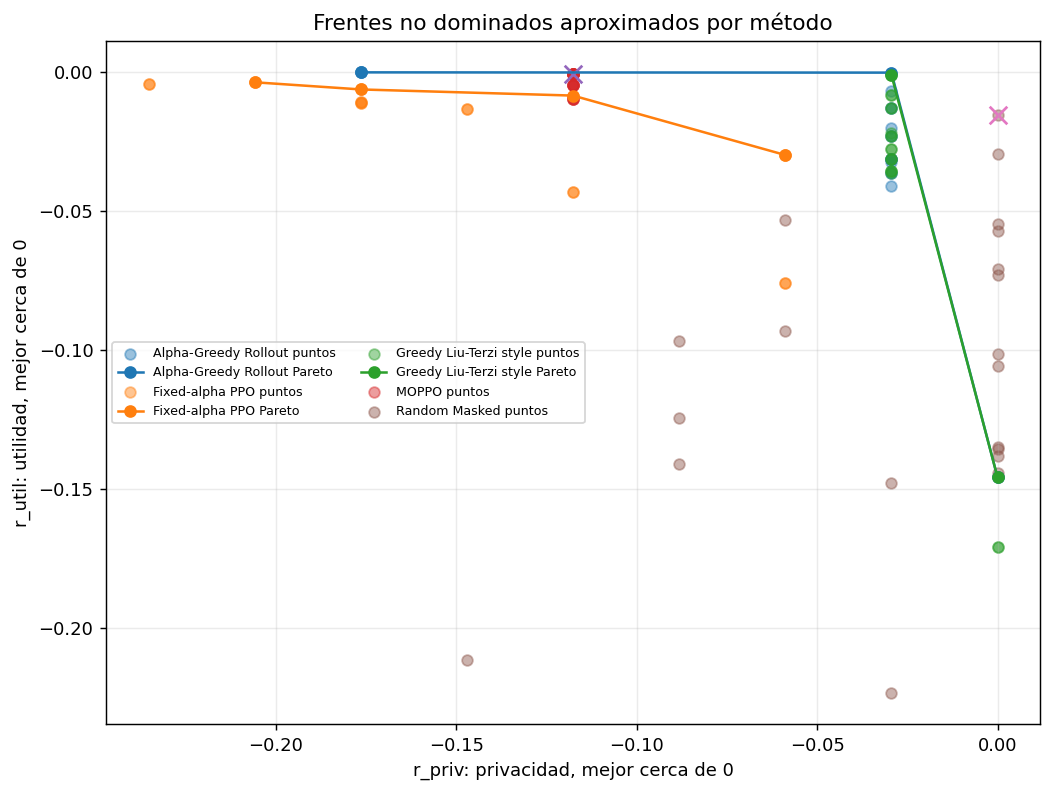

Guardado: outputs_moppo_baselines_autocontenido/fig_07_regret_by_alpha.png


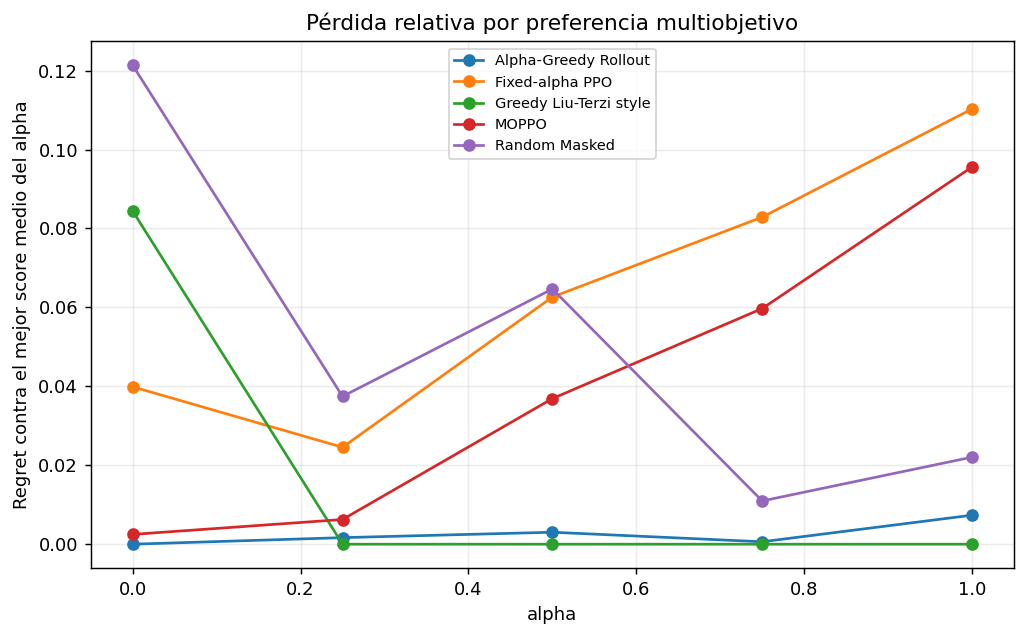

Guardado: outputs_moppo_baselines_autocontenido/fig_08_score_stability_by_seed.png


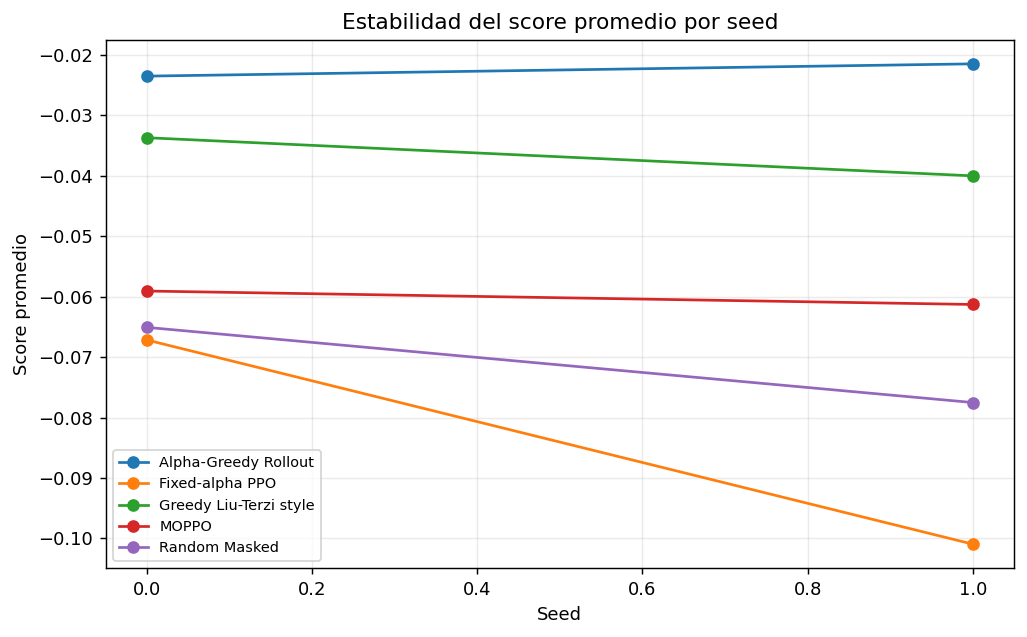

Guardado: outputs_moppo_baselines_autocontenido/fig_09_privacy_vs_edge_cost.png


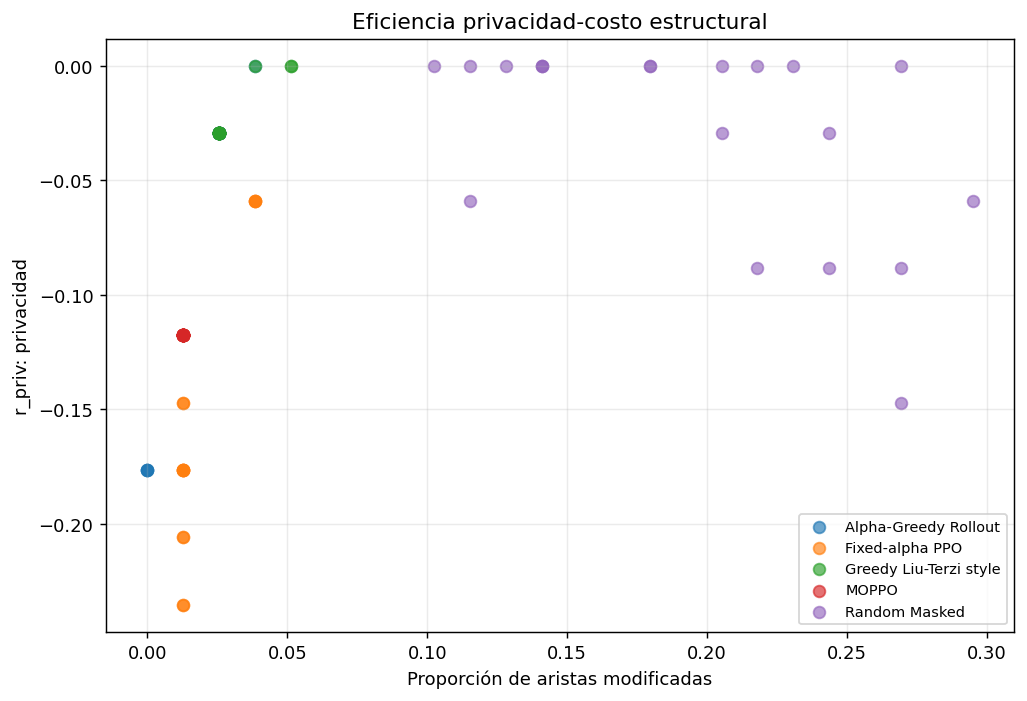

Guardado: outputs_moppo_baselines_autocontenido/fig_10_clustering_preservation_by_alpha.png


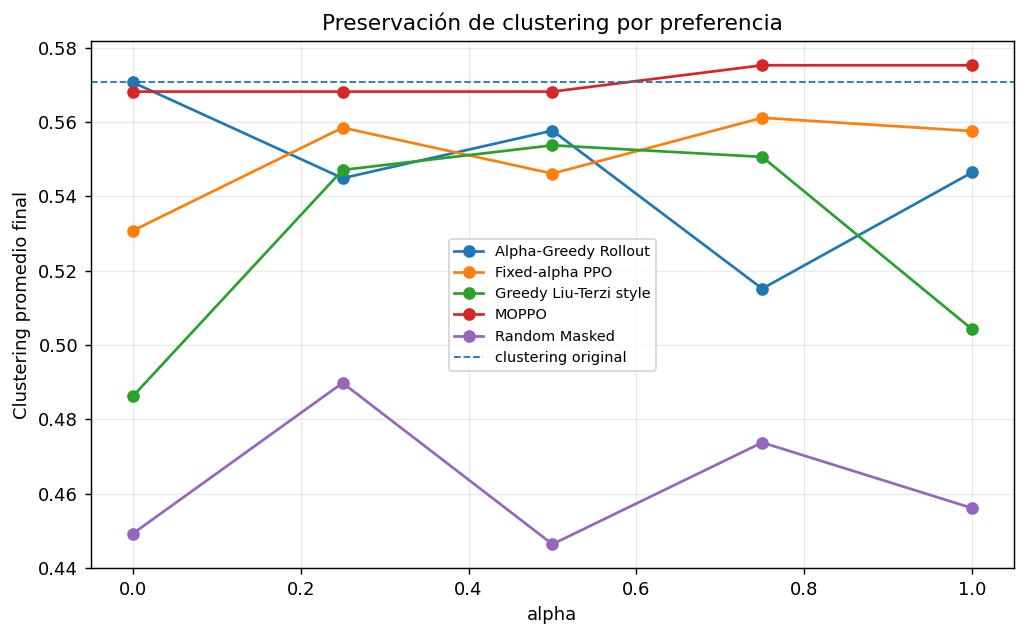

Guardado: outputs_moppo_baselines_autocontenido/fig_11_heatmap_score_method_alpha.png


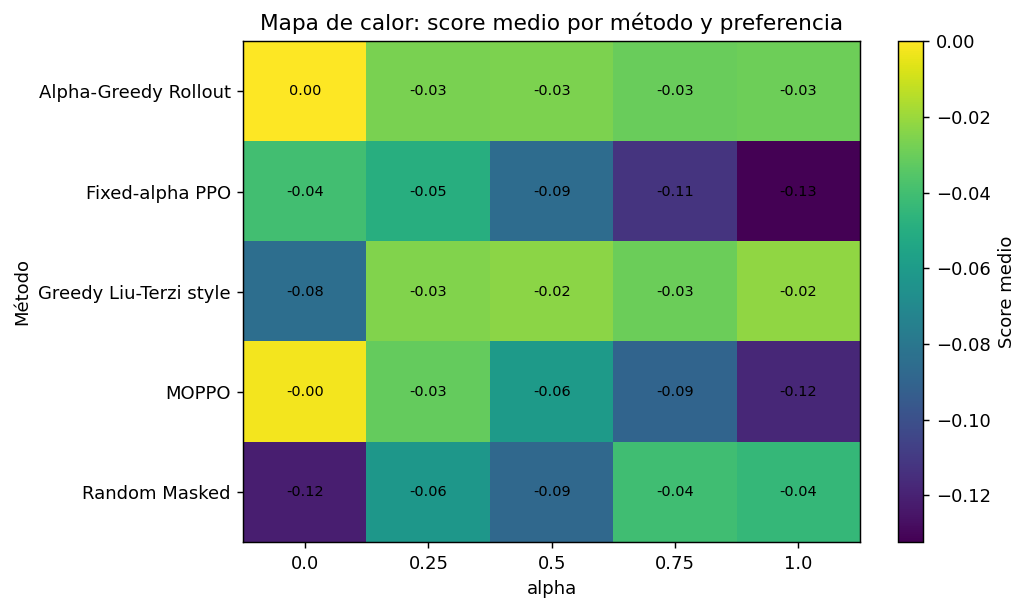

In [14]:
plt.figure(figsize=(8.2, 6.2))
for method, dfm in results.groupby('method'):
    pts = list(zip(dfm['r_priv'], dfm['r_util']))
    front = compute_pareto_front(pts)
    plt.scatter(dfm['r_priv'], dfm['r_util'], s=35, alpha=0.45, label=f'{method} puntos')
    if len(front) >= 2:
        fx, fy = zip(*front)
        plt.plot(fx, fy, marker='o', linewidth=1.4, label=f'{method} Pareto')
    elif len(front) == 1:
        plt.scatter([front[0][0]], [front[0][1]], s=95, marker='x')
plt.xlabel('r_priv: privacidad, mejor cerca de 0')
plt.ylabel('r_util: utilidad, mejor cerca de 0')
plt.title('Frentes no dominados aproximados por método')
plt.grid(True, alpha=0.25)
plt.legend(fontsize=7, ncol=2)
savefig('fig_06_pareto_fronts_by_method.png')
plt.show()

plt.figure(figsize=(8, 5))
for method, dfm in regret_table.groupby('method'):
    dfm = dfm.sort_values('alpha')
    plt.plot(dfm['alpha'], dfm['regret_to_best_alpha'], marker='o', label=method)
plt.xlabel('alpha')
plt.ylabel('Regret contra el mejor score medio del alpha')
plt.title('Pérdida relativa por preferencia multiobjetivo')
plt.grid(True, alpha=0.25)
plt.legend(fontsize=8)
savefig('fig_07_regret_by_alpha.png')
plt.show()

seed_summary = results.groupby(['method', 'seed'], as_index=False)['score'].mean()
plt.figure(figsize=(8, 5))
for method, dfm in seed_summary.groupby('method'):
    plt.plot(dfm['seed'], dfm['score'], marker='o', label=method)
plt.xlabel('Seed')
plt.ylabel('Score promedio')
plt.title('Estabilidad del score promedio por seed')
plt.grid(True, alpha=0.25)
plt.legend(fontsize=8)
savefig('fig_08_score_stability_by_seed.png')
plt.show()

plt.figure(figsize=(8, 5.5))
for method, dfm in results.groupby('method'):
    plt.scatter(dfm['edge_change_ratio'], dfm['r_priv'], s=42, alpha=0.65, label=method)
plt.xlabel('Proporción de aristas modificadas')
plt.ylabel('r_priv: privacidad')
plt.title('Eficiencia privacidad-costo estructural')
plt.grid(True, alpha=0.25)
plt.legend(fontsize=8)
savefig('fig_09_privacy_vs_edge_cost.png')
plt.show()

plt.figure(figsize=(8, 5))
for method, dfm in results.groupby('method'):
    ordered = dfm.groupby('alpha', as_index=False)['final_clustering'].mean().sort_values('alpha')
    plt.plot(ordered['alpha'], ordered['final_clustering'], marker='o', label=method)
plt.axhline(nx.average_clustering(G0), linestyle='--', linewidth=1, label='clustering original')
plt.xlabel('alpha')
plt.ylabel('Clustering promedio final')
plt.title('Preservación de clustering por preferencia')
plt.grid(True, alpha=0.25)
plt.legend(fontsize=8)
savefig('fig_10_clustering_preservation_by_alpha.png')
plt.show()

pivot_score = summary_alpha.pivot(index='method', columns='alpha', values='score_mean')
plt.figure(figsize=(8, 4.8))
plt.imshow(pivot_score.values, aspect='auto')
plt.xticks(range(len(pivot_score.columns)), [str(a) for a in pivot_score.columns])
plt.yticks(range(len(pivot_score.index)), pivot_score.index)
plt.colorbar(label='Score medio')
plt.xlabel('alpha')
plt.ylabel('Método')
plt.title('Mapa de calor: score medio por método y preferencia')
for i in range(pivot_score.shape[0]):
    for j in range(pivot_score.shape[1]):
        val = pivot_score.iloc[i, j]
        plt.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8)
savefig('fig_11_heatmap_score_method_alpha.png')
plt.show()

## 9.2 Casos de estudio: trayectoria y cambio estructural

Las métricas agregadas pueden ocultar comportamientos importantes. Por eso, este bloque inspecciona una corrida específica. El objetivo no es reemplazar la evaluación estadística, sino mostrar cualitativamente cómo una política transforma el grafo paso a paso.

,step,method,action,r_priv,r_util,score,edge_change_ratio
0,0,Random Masked,52,-0.1471,-0.0279,-0.1173,0.0128
1,1,Random Masked,455,-0.0882,-0.0576,-0.0806,0.0256
2,2,Random Masked,82,-0.0882,-0.0677,-0.0831,0.0385
3,3,Random Masked,181,-0.0882,-0.0745,-0.0848,0.0513
4,4,Random Masked,406,-0.0882,-0.1037,-0.0921,0.0641


Guardado: outputs_moppo_baselines_autocontenido/fig_12_trace_privacy.png


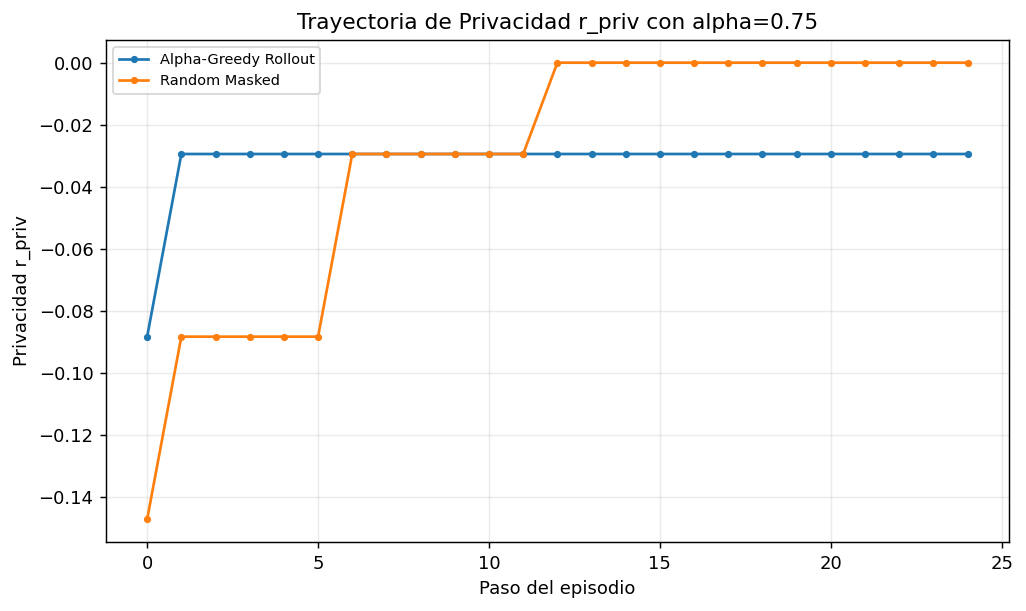

Guardado: outputs_moppo_baselines_autocontenido/fig_13_trace_utility.png


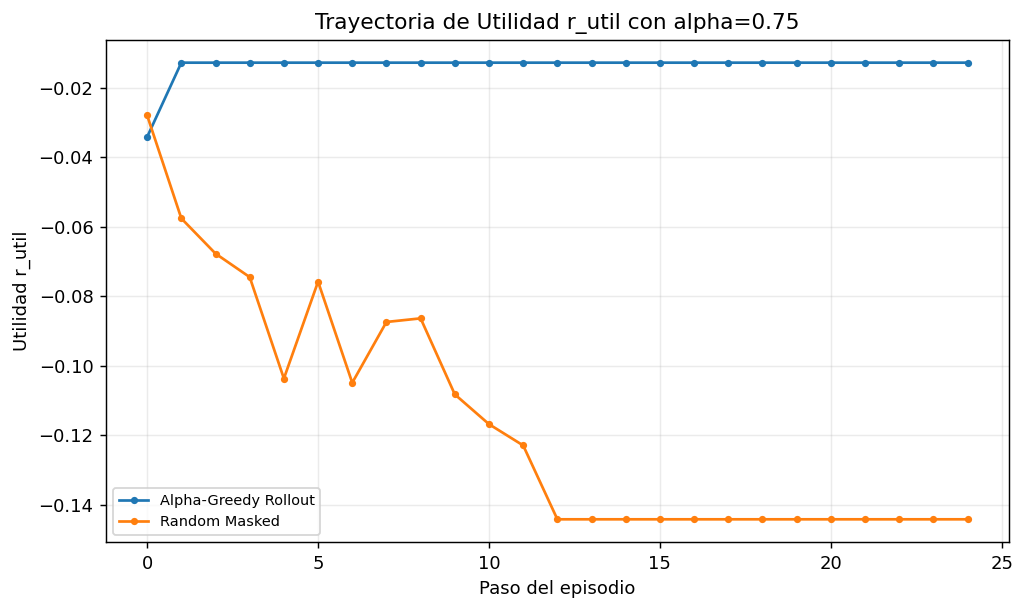

Guardado: outputs_moppo_baselines_autocontenido/fig_14_trace_score.png


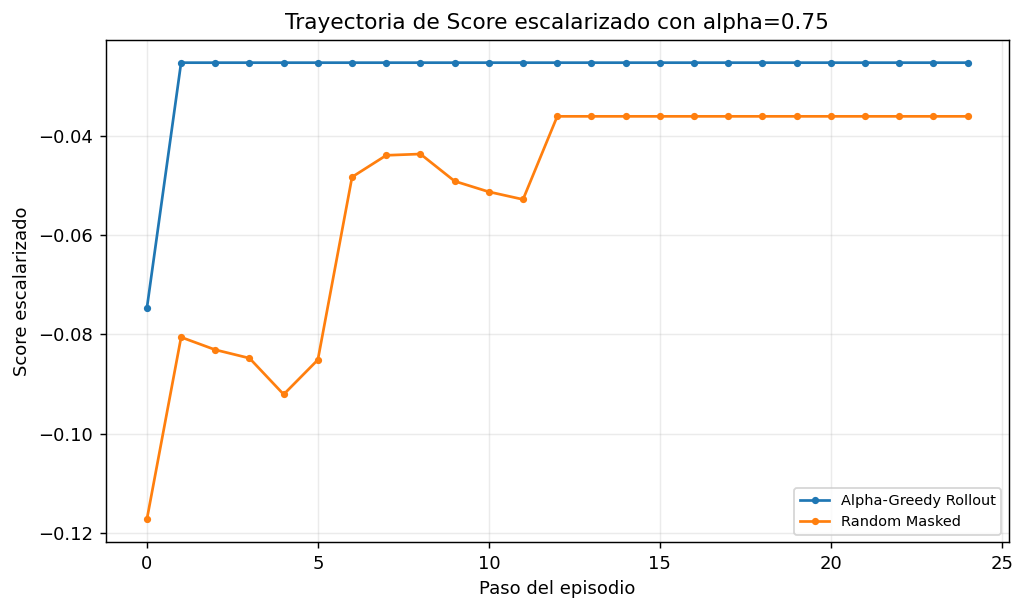

Guardado: outputs_moppo_baselines_autocontenido/fig_15_trace_edge_change.png


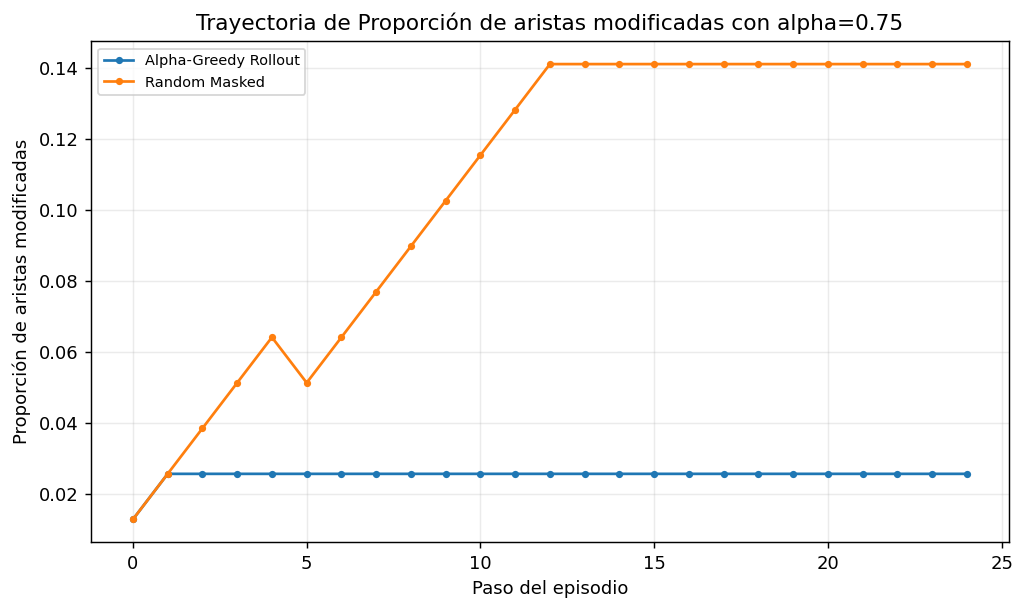

Guardado: outputs_moppo_baselines_autocontenido/fig_16_before_after_alpha_greedy.png


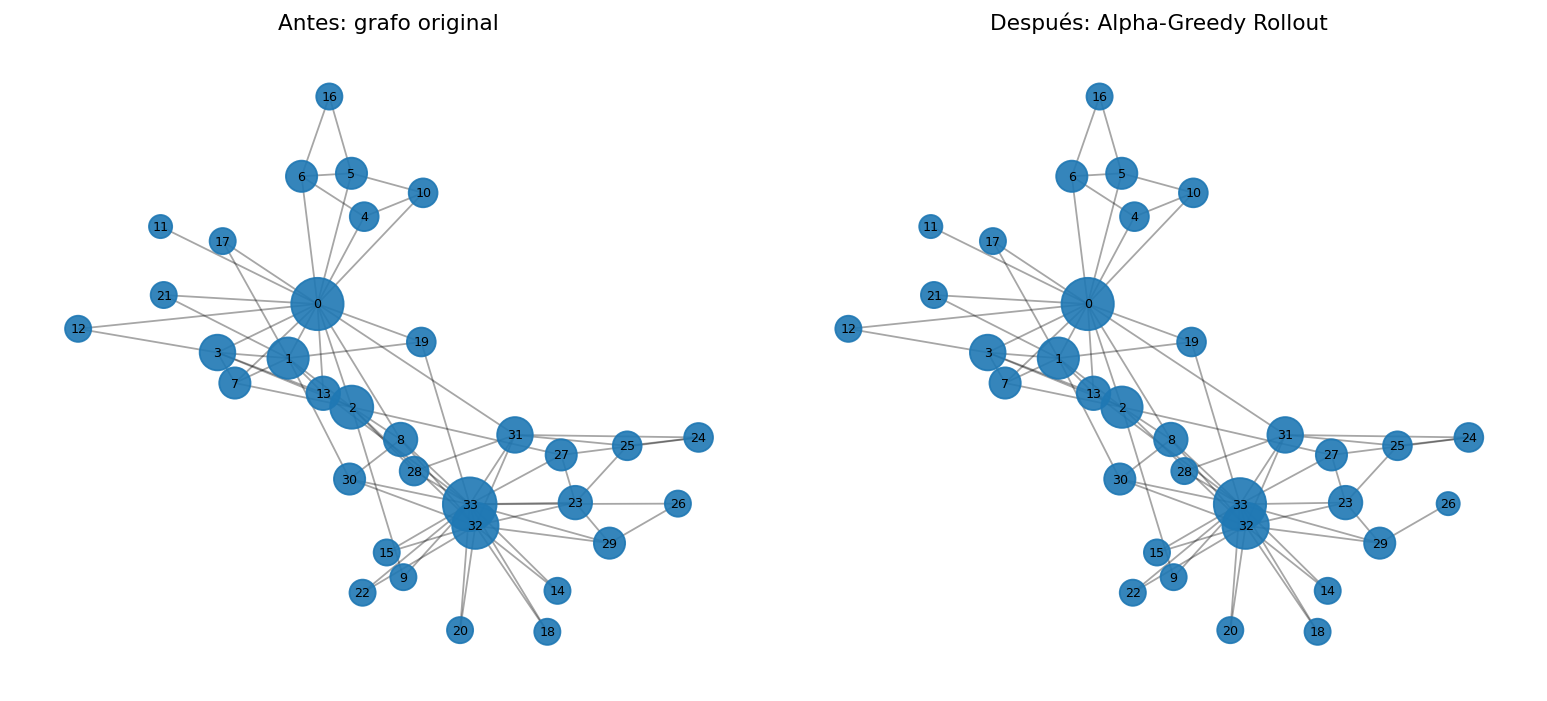

Guardado: outputs_moppo_baselines_autocontenido/fig_17_degree_distribution_before_after.png


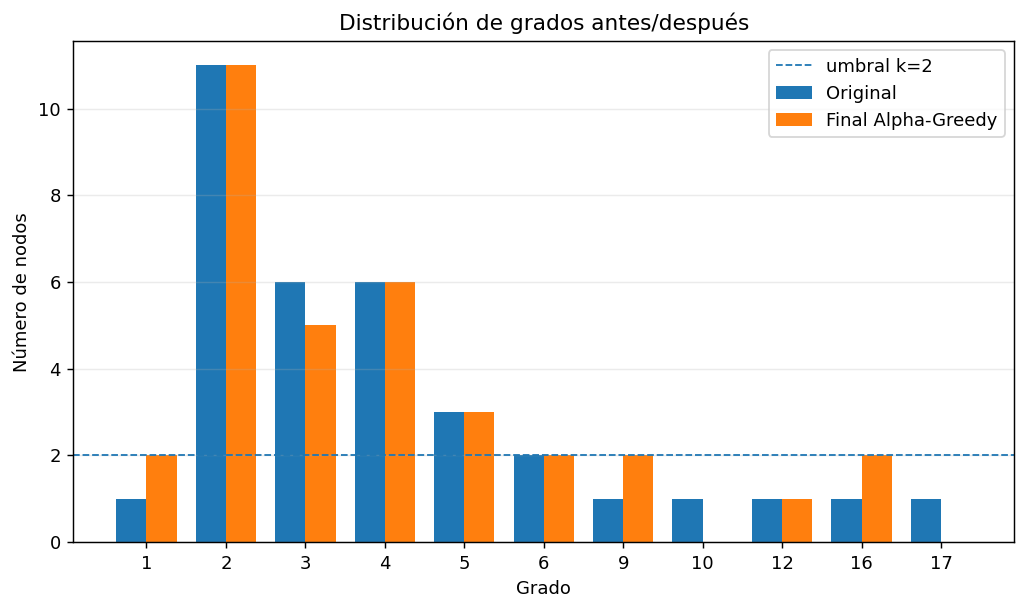

In [15]:
def trace_random_masked(G0, seed, alpha):
    rng = np.random.default_rng(seed + int(alpha * 1000) + 101)
    env = GraphAnonEnv(G0, k=K_ANON, T=EPISODE_LEN)
    env.reset(seed=seed, weight=[alpha, 1.0 - alpha])
    rows = []
    done = False
    step = 0
    while not done:
        valid = np.flatnonzero(env.get_action_mask())
        action = int(rng.choice(valid))
        _, _, done, _ = env.step(action)
        rp = compute_k_anonymity_reward(env.G, env.k)
        ru = compute_utility_reward(env.G, env.G0)
        rows.append({'step': step, 'method': 'Random Masked', 'action': action, 'r_priv': rp, 'r_util': ru, 'score': scalar_score(rp, ru, alpha), 'edge_change_ratio': edge_change_ratio(env.G, env.G0)})
        step += 1
    return pd.DataFrame(rows), env.G.copy()


def trace_alpha_greedy(G0, seed, alpha, max_candidates=50):
    rng = np.random.default_rng(seed + int(alpha * 1000) + 303)
    env = GraphAnonEnv(G0, k=K_ANON, T=EPISODE_LEN)
    env.reset(seed=seed, weight=[alpha, 1.0 - alpha])
    rows = []
    done = False
    step = 0
    stagnant = 0
    while not done:
        current_rp = compute_k_anonymity_reward(env.G, env.k)
        current_ru = compute_utility_reward(env.G, env.G0)
        current_score = scalar_score(current_rp, current_ru, alpha)
        candidates = candidate_actions_from_mask(env, max_candidates=max_candidates, rng=rng) + [env.NO_OP]
        scored = [(*simulate_action_score(env, a, alpha=alpha, use_true_utility=False), a) for a in candidates]
        scored.sort(reverse=True)
        best_score, _, _, best_action = scored[0]
        if best_score > current_score + 1e-10:
            action = best_action
            stagnant = 0
        else:
            action = env.NO_OP
            stagnant += 1
        _, _, done, _ = env.step(action)
        rp = compute_k_anonymity_reward(env.G, env.k)
        ru = compute_utility_reward(env.G, env.G0)
        rows.append({'step': step, 'method': 'Alpha-Greedy Rollout', 'action': action, 'r_priv': rp, 'r_util': ru, 'score': scalar_score(rp, ru, alpha), 'edge_change_ratio': edge_change_ratio(env.G, env.G0)})
        step += 1
        if stagnant >= 3:
            while not done:
                _, _, done, _ = env.step(env.NO_OP)
                rp = compute_k_anonymity_reward(env.G, env.k)
                ru = compute_utility_reward(env.G, env.G0)
                rows.append({'step': step, 'method': 'Alpha-Greedy Rollout', 'action': env.NO_OP, 'r_priv': rp, 'r_util': ru, 'score': scalar_score(rp, ru, alpha), 'edge_change_ratio': edge_change_ratio(env.G, env.G0)})
                step += 1
    return pd.DataFrame(rows), env.G.copy()

EXAMPLE_ALPHA = 0.75
EXAMPLE_SEED = SEEDS[0]
trace_random, G_random_final = trace_random_masked(G0, EXAMPLE_SEED, EXAMPLE_ALPHA)
trace_greedy, G_alpha_greedy_final = trace_alpha_greedy(G0, EXAMPLE_SEED, EXAMPLE_ALPHA)
trace_df = pd.concat([trace_random, trace_greedy], ignore_index=True)
trace_df.to_csv(OUTPUT_DIR / 'example_trajectory_trace.csv', index=False)
display(trace_df.head())

for metric, ylabel, filename in [
    ('r_priv', 'Privacidad r_priv', 'fig_12_trace_privacy.png'),
    ('r_util', 'Utilidad r_util', 'fig_13_trace_utility.png'),
    ('score', 'Score escalarizado', 'fig_14_trace_score.png'),
    ('edge_change_ratio', 'Proporción de aristas modificadas', 'fig_15_trace_edge_change.png'),
]:
    plt.figure(figsize=(8, 4.8))
    for method, dfm in trace_df.groupby('method'):
        plt.plot(dfm['step'], dfm[metric], marker='o', markersize=3, label=method)
    plt.xlabel('Paso del episodio')
    plt.ylabel(ylabel)
    plt.title(f'Trayectoria de {ylabel} con alpha={EXAMPLE_ALPHA}')
    plt.grid(True, alpha=0.25)
    plt.legend(fontsize=8)
    savefig(filename)
    plt.show()

plt.figure(figsize=(12, 5.5))
plt.subplot(1, 2, 1)
nx.draw_networkx_edges(G0, pos, alpha=0.35)
nx.draw_networkx_nodes(G0, pos, node_size=[120 + 45 * G0.degree(v) for v in G0.nodes()], alpha=0.9)
nx.draw_networkx_labels(G0, pos, font_size=7)
plt.title('Antes: grafo original')
plt.axis('off')
plt.subplot(1, 2, 2)
nx.draw_networkx_edges(G_alpha_greedy_final, pos, alpha=0.35)
nx.draw_networkx_nodes(G_alpha_greedy_final, pos, node_size=[120 + 45 * G_alpha_greedy_final.degree(v) for v in G_alpha_greedy_final.nodes()], alpha=0.9)
nx.draw_networkx_labels(G_alpha_greedy_final, pos, font_size=7)
plt.title('Después: Alpha-Greedy Rollout')
plt.axis('off')
savefig('fig_16_before_after_alpha_greedy.png')
plt.show()

plt.figure(figsize=(8, 4.8))
orig_counts = pd.Series([d for _, d in G0.degree()]).value_counts().sort_index()
final_counts = pd.Series([d for _, d in G_alpha_greedy_final.degree()]).value_counts().sort_index()
all_degrees = sorted(set(orig_counts.index).union(final_counts.index))
x = np.arange(len(all_degrees))
width = 0.38
plt.bar(x - width/2, [orig_counts.get(d, 0) for d in all_degrees], width=width, label='Original')
plt.bar(x + width/2, [final_counts.get(d, 0) for d in all_degrees], width=width, label='Final Alpha-Greedy')
plt.axhline(K_ANON, linestyle='--', linewidth=1, label=f'umbral k={K_ANON}')
plt.xticks(x, all_degrees)
plt.xlabel('Grado')
plt.ylabel('Número de nodos')
plt.title('Distribución de grados antes/después')
plt.grid(True, axis='y', alpha=0.25)
plt.legend()
savefig('fig_17_degree_distribution_before_after.png')
plt.show()

## 10. Tabla final para el reporte

La tabla resume los métodos principales.  
Puedes pegar el CSV en Excel o usar directamente el `.tex` si el reporte está en LaTeX.

In [16]:
report_table = summary_method.copy()
for col in ['r_priv_mean', 'r_util_mean', 'score_mean', 'edge_change_mean', 'hypervolume']:
    report_table[col] = report_table[col].round(4)
report_table = report_table[[
    'method', 'hypervolume', 'pareto_size', 'score_mean', 'r_priv_mean',
    'r_util_mean', 'edge_change_mean', 'n'
]]

csv_path = OUTPUT_DIR / 'report_table.csv'
tex_path = OUTPUT_DIR / 'report_table.tex'
report_table.to_csv(csv_path, index=False)
report_table.to_latex(tex_path, index=False, escape=False)

print('CSV:', csv_path)
print('LaTeX:', tex_path)
display(report_table)

CSV: outputs_moppo_baselines_autocontenido/report_table.csv
LaTeX: outputs_moppo_baselines_autocontenido/report_table.tex


,method,hypervolume,pareto_size,score_mean,r_priv_mean,r_util_mean,edge_change_mean,n
4,Random Masked,0.9845,1,-0.0713,-0.0294,-0.1076,0.1955,20
2,Greedy Liu-Terzi style,0.9697,2,-0.0369,-0.0250,-0.0445,0.0288,20
3,MOPPO,0.8819,1,-0.0602,-0.1176,-0.0035,0.0128,20
0,Alpha-Greedy Rollout,0.8235,3,-0.0225,-0.0574,-0.0257,0.0212,20
1,Fixed-alpha PPO,0.7913,4,-0.0841,-0.1471,-0.0206,0.0179,20




Esto deja trazabilidad para que el experimento sea reproducible.

In [19]:
config = {
    'graph_name': GRAPH_NAME,
    'n_nodes_random': N_NODES_RANDOM,
    'k_anon': K_ANON,
    'episode_len': EPISODE_LEN,
    'alphas': ALPHAS,
    'seeds': SEEDS,
    'n_iter_moppo': N_ITER_MOPPO,
    'n_iter_fixed': N_ITER_FIXED,
    'n_steps': N_STEPS,
    'n_episodes_eval': N_EPISODES_EVAL,
    'hidden_dim': HIDDEN_DIM,
    'lr': LR,
    'gamma': GAMMA,
    'lambda_gae': LAMBDA_GAE,
    'clip_eps': CLIP_EPS,
    'device': str(DEVICE),
}
with open(OUTPUT_DIR / 'experiment_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(json.dumps(config, indent=2))
print('\nTodo quedó guardado en:', OUTPUT_DIR.resolve())

{
  "graph_name": "karate",
  "n_nodes_random": 30,
  "k_anon": 2,
  "episode_len": 25,
  "alphas": [
    0.0,
    0.25,
    0.5,
    0.75,
    1.0
  ],
  "seeds": [
    0,
    1
  ],
  "n_iter_moppo": 15,
  "n_iter_fixed": 10,
  "n_steps": 128,
  "n_episodes_eval": 2,
  "hidden_dim": 128,
  "lr": 0.0003,
  "gamma": 0.99,
  "lambda_gae": 0.95,
  "clip_eps": 0.2,
  "device": "cpu"
}

Todo quedó guardado en: /content/outputs_moppo_baselines_autocontenido
